## Site Term calculation

This notebook contains all the calculations and functions to structurally find the site term for each station. In order to do so the following steps are being followed:

- #### 1. Data Download : 
    <small>from disk or downloaded all the stations for each event given in a csv file that resembles a normal query from USGS or EMSC. The Instrument response is deconvolved, if read from disk this is already done.</small>

- #### 2. SNR calculation:
    <small> for each station and event the SNR ratio should be calculated of each arrival towards a noise window which is set pre event. Based on the mean SNR of the body wave arrivals, a cutoff distance is set, where 90% of the stations have a higher Lg wave SNR than a threshold (a threshold of 3.5 is advised). Based on this stations who generally have a lower SNR, or have a higher event-station distance will be filtered out. </small>

- #### 3. Seismogram envelope calculation
    <small> now we calculate the envelopes of each seismogram that is left after filtering based on the SNR and the cutoff distance.  This is done with the Hilbert transform: $${ E(t)={\sqrt {({{Re }}(s(t)))^{2}+({{Im }}(s(t)))^{2}}}}$$, where the Real part is the trace itself and the imaginary part its Hilbert transform. Then we take care of sampling rates, we only consider traces with a sampling rate higher than 10Hz. The envelopes are subsequently smoothed over with a moving average box of 50 seconds width.</small>

- #### 4. Setting of coda time window
    <small> since we want to get rid of the Site term, and we assume that for long enough lapse times the record is independent of distance, source and radiation term, we propose a normalisation of each amplitude by the ratio of the amplitudes within a code time window between each station and a reference station. Doing this, we correct each station in relation to one reference station, which leaves us only with the attenuation term and the source term in the amplitude expression. Therefore it is of large importance to choose a coda time window, which is well in the coda, but at the same time has sufficient energy, in order not to be disturbed by direct arrivals or being nothing but noise. We set the coda time window in dependance of the cutoff distance. The cutoff distance defines the radius we consider, so the largest event-station distance. We divide the cutoff distance by a velocity of 3km/s, which is slower than the body waves, Lg waves and about the velocity of a surface wave. Then we multiply this time by a factor (preferably 1.1), to make sure we really do not consider any direct arrivals. Using this theorem we end upp with rather good coda SNR, while being already good in the parallel regime regarding the slopes of the envelopes. This coda time window is in theory directly computed in step 2, where the cutoff distance is calculated. </small>

- #### 5. Testing of coda time window
    <small> In order to find out if the time window is in fact appropriate, several tests can be run. First of all a visual inspection of the envelopes can be done, with the coda time window plotted on it. Fundamentally the envelopes should be parallel to one another, meaning independent of the distance between station and event the amplitude decays similarly. This can be quantified by looking at the slopes of each envelope within the window. Another test can be done, which already comes close to the actual site term calculation. We divide two smoothed envelopes from one another, one could be a potential reference station. If we are well in the scattering regime, the ratio of the two traces should be rather horizontal, towards zero slope. However, the same applies to the noise regime, where the ratio also has no slope. </small>

- #### 6. SNR computation of the coda time window
    <small> Clearly stations that have poor SNR also in the coda, can not be considered, in order not to introduce a bias. So in order to only use meaningful and physical datapoints we force two criteria. One is a SNR higher than 2 for the whole coda time window, the other is a SNR higher than 2 for the last 20 seconds of the coda time window. By doing this we get rid of stations that have generally weak coda SNR, but also of those who enter already in the noise towards the end of the window. </small>

- #### 7. Find a reference station for each event
    <small> Subsequently, a reference station has to be found for each event. We choose a Geoscope station to be the global reference station, since it recorded for a long time and high quality. We choose station SSB, which recorded 82 out of 94 events from the preliminary catalogue, 17 of which recordings fulfill the two criteria. In case an event is not recorded by the main reference station, a list of other fallback stations is checked. For each of the fallback stations as many events as possible are found, where the fallback station and the main reference station have simultaneously recorded and have a coda SNR higher than 2. Then the ratio between the amplitudes of the coda within the window at both station is computed, of which the median is taken. If in fact an event is not or not sufficiently enough recorded by the main reference station, the median ratio of the fallback station and the main reference station is used to approach the reference station: $$med(\frac{A_{reference}}{A_{fallback}}) \cdot A_{fallback}(event)$$. </small>

- #### 8. Calculation of the Site Term
    <small> When all the possible amplitude ratios are calculated, the final site term for each station can be found. This is done by defining the median of all available measurements as the site term, the advantage being here that we have an idea about the standard deviation.</small>

- #### 9. Following all the previous steps for several frequency bands
    <small> Since the site term is frequency dependent, we need to go through all the steps above individually for all needed frequency bands. </small>


<br/><br/><br/><br/><br/><br/>

Sehr geehrte Damen und Herren,

auf der Suche nach einer Moeglichkeit nach meinem Masterstudium in einem spannenden Forschungsthema sowie politisch und gesellschaftlich wichtigen Bereich zu arbeiten, habe ich Ihr Angebot entdeckt. 
Mein Name ist Leon Schreiner, und ich bin aktuell Master Student an der Universite Grenoble Alpes im Studiengang Geophysics and Earth Imaging. Im moment schliesse ich das Studium ab, und befinde mich in der Master Thesis. Meine aktuelle Arbeit ist im Bereich der Seismologie, meine Kolleg*innen und ich beschaeftigen uns mit der Erforschung und Kartierung der Ausbreitung der Lg Welle, welche eine spezifische Welle ist, die sich nach Erdbeben in der kontinentalen Erdkruste ausbreitet. Meinen Bachelor habe ich am Karlsruher Institut fuer Technologie absolviert, ebenfalls in Geophysik mit Schwerpunktfach Ingenieurs- und Hydrogeologie.

Ich bin sehr begeistert von dem von Ihnen angebotenen Traineeship, ich denke es bietet viele Moeglichkeiten sowohl in wissenschaftlich exzellenten Einrichtungen, wie dem BGR, zu arbeiten, als auch Feldarbeit und die Anwendung der Forschung im Sinne von Aufbereitung der interpretierten Datensaetze vor Ort in Amman zu absolvieren. Ich bin es gewohnt mit grossen und komplexen Datenstrukturen und Saetzen zu arbeiten, und mithilfe computergestuetzter Auswertung Interpretationsansaetze zu erarbeiten. Allerdings ist eine direkte Zusammenarbeit mit einer Organisation wie der WAJLabs und generell dem WEF Nexus in Jordanien fuer mich etwas neues, wie auch eine grosse Motivation. Etwas so essentielles wie eine sichere und dauerhafte Wasserversorgung zu gewaehrleisten, oder mit Forschung und Datenauswertung zumindest zu unterstuetzen ist fuer mich sehr motivierend und der Kern angewandter Forschung. 

Ganz persoenlich sehe ich das Traineeship als Chance, das Wissen, die Vorgehensweisen und vor allen Dingen den wissenschaftlichen Umgang mit Problemen und Daten, das ich mir waehrend des Studiums angeeignet habe in einem Projekt mit spannendem und wichtigem Bezug anzuwenden, und mein fachliches Wissen sowie andere Faehigkeiten zu erweitern. Ich habe wie bereits erwaehnt Erfahrung im wissenschaftlichen Umfeld, habe kuerzere (jeweils um die 2 Monate) Praktikumsaufenthalte am AWI und GFZ absolviert, und meine Bachelorthesis am Geophysikalischen Institut des KIT geschrieben. Fuer meine Masterarbeit bin ich aktuell am ISTerre in Grenoble. Ich habe sehr gute Programmierkentnisse, bin dazu imstande physikalische Konzepte mit grossen Datenmengen zu hinterfragen und zu erarbeiten, und selbststaendig Daten mit Sicht auf Interpretation darzustellen.

Darueber hinaus habe ich durch mehrere laengere Aufenthalten in Indien sowie dem suedasiatischen Raum interkulturelle Kompetenz, und bin es gewohnt mich neuen Begebenheiten anzupassen. Ich spreche fliessend Englisch, und kann mich gut auf Franzoesisch verstaendigen, nach 19 Monaten Leben in Frankreich.

Ich bin mir im klaren dass ich nicht der perfekte Kandidat fuer das Projekt bin, da sich meine Erfahrungen hauptsaechlich in der Seismologie sowie theoretischen Geophysik befinden, und ich bis Ende Juli noch am ISTerre gebunden bin. Jedoch habe ich durch meine Wahl der Ingenieurs- und Hydrogeologie im Bachelor sowie einer einwoechigen Exkursion grundlegende Kenntnisse, und bin sehr sicher in Signalverarbeitung sowie Datenverarbeitung generell. Ich waere sehr motiviert ein Teil des Projekts zu sein, und mich persoenlich weiter zu bilden wie auch eine unterstuetzende und im Rahmen der Moeglichkeiten tragenden Rolle auszufuellen.

Ich haette einige Fragen zum Projekt selbst, ueber die Methodik, die interdisziplinaere Ausrichtung sowie zu innovativen Moeglichkeiten des Grundwasser Monitorings. Ich wuerde mich sehr ueber eine Ruckmeldung jeder Art, und moeglicherweise ein Gespraech freuen.

Mit freundlichen Gruessen,
Leon Schreiner




#### 1. Data download

In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
import random
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm
from scipy.signal import resample
from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.


5.7


In [2]:
from new_functions import *


/home/schreinl/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
catalogue = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
catalogue = catalogue[catalogue['mag'] >= 4.0].reset_index(drop=True)
catalogue = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
catalogue = catalogue[catalogue['mag'] >= 4.0].reset_index(drop=True)
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
carte = folium.Map([45, 7], zoom_start=5)

for _, row in catalogue.iterrows():
    infos = f"{row['time']} ({row['latitude']}, {row['longitude']}) {row['mag']} m"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        tooltip=infos,
        fill=True,
        fill_opacity=1.0,
        radius=4,
    ).add_to(carte)

carte

2020-12-29T14:36:31.473000Z
Earthquake at 2020-12-29T14:36:56.473000Z with magnitude 4.6


Processing stations of INGV:  57%|█████▋    | 137/242 [00:03<00:03, 32.98it/s]

no Sn  0.8233800477683854 list index out of range


Processing stations of INGV:  82%|████████▏ | 198/242 [00:05<00:01, 37.83it/s]

no Sn  0.8405579106507378 list index out of range
no Sn  0.8761115528233053 list index out of range


...

Processing stations of BGR:  58%|█████▊    | 103/177 [01:52<01:43,  1.40s/it]

1 Trace(s) in Stream:
HS.WBA..HHZ | 2020-12-29T14:36:31.470000Z - 2020-12-29T14:48:11.470000Z | 100.0 Hz, 70001 samples False


Processing stations of BGR:  60%|█████▉    | 106/177 [01:55<01:14,  1.05s/it]

1 Trace(s) in Stream:
HS.WBFO..HHZ | 2020-12-29T14:36:31.470000Z - 2020-12-29T14:48:11.470000Z | 100.0 Hz, 70001 samples False


Processing stations of BGR: 100%|██████████| 177/177 [03:02<00:00,  1.03s/it]
Processing stations of http://fdsnws.sismologia.ign.es: 100%|██████████| 16/16 [00:08<00:00,  1.81it/s]


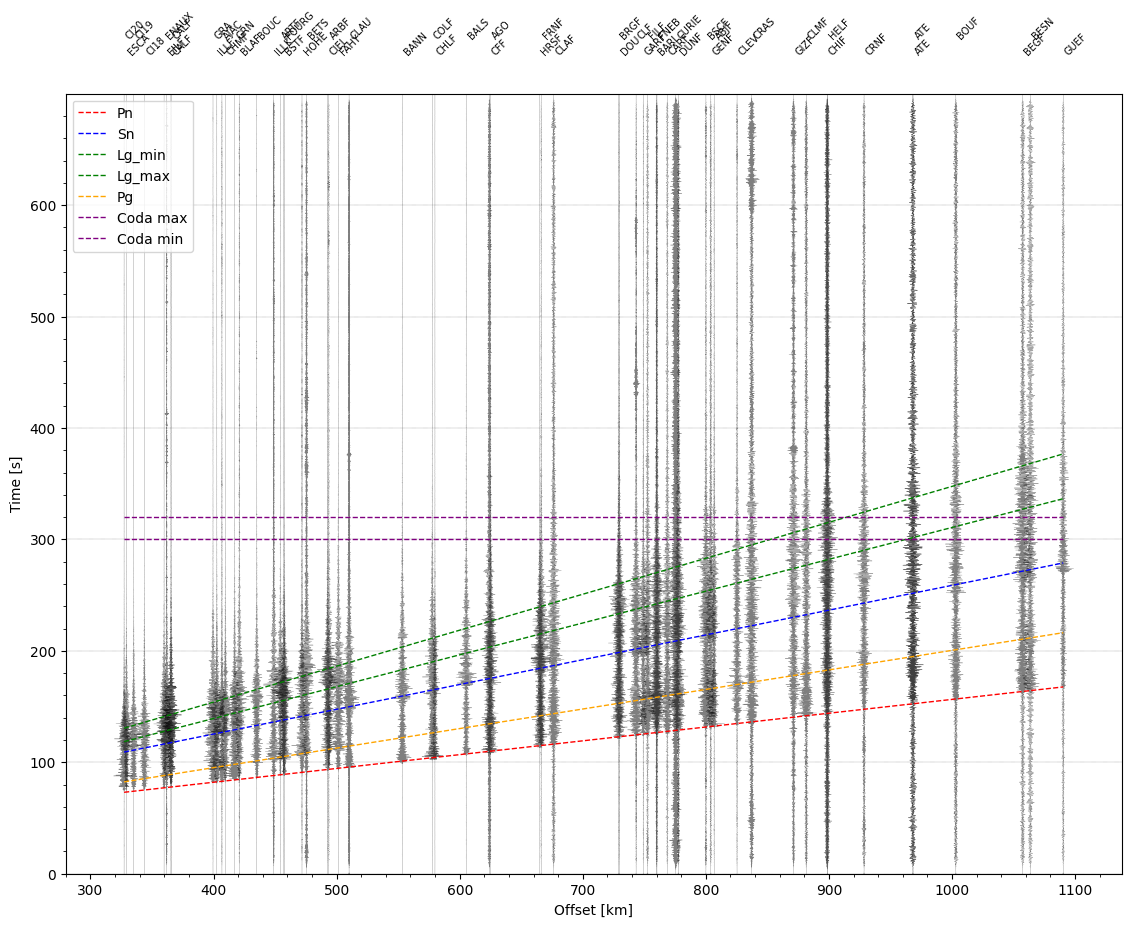

In [4]:


from obspy.clients.fdsn import Client

import warnings
warnings.filterwarnings("ignore")
datacenters =['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory='/home/schreinl/Stage/Data1/'
distmin=0.5
distmax=10.
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)


start = UTCDateTime(catalogue_5['time'][29]) -25
print(start)
end = start + 700
eq_lon = float(catalogue_5['longitude'][29])
eq_lat = float(catalogue_5['latitude'][29])





st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")







st_plot_filt_all=st_all.copy()
fmin=1
fmax=5
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)



plot, st_Lg0 = plot_record_section(st_plot_filt_all[0:60], stations_all[0:60], eq_lat, 
eq_lon, start, tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, 
v_Pg=vPg)





#### 2. SNR calculation/4. Setting of coda time window

In [5]:
snr_threshold = 3.5
eq_start = start

filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_test, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="cutoff",factor=1.1)
amp_plot

calculating SNR for Pn  phase
calculating SNR for Pg  phase
calculating SNR for Sn  phase
calculating SNR for Lg  phase
Reduced from   814  stations to   674  stations due to insufficient SNR or distance >  756.3641309359924
coda window set from 277.33351467653057-377.33351467653057s based on Lg cutoff distance
plotting Lg_Coda amplitudes


###  3. Seismogram Envelope calculation

In [52]:
def envelope_processing(st,stations,time_string,station_ref,filtered_stations_with_SNR,Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_start, coda_duration, Dtmin_Noise, Dtmax_Noise, eq_start):
    '''

    '''
    
    st_envelope = obspy.Stream()
    smallest = 7000
    for tr in st:
        data_envelope = envelope_calculator(tr.data)
        npts = tr.stats.npts
        if npts >= smallest:
            samprate = tr.stats.sampling_rate
            t = np.arange(0, npts / samprate, 1 / samprate)
            tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
            st_envelope.append(tr_envelope)
    print("calculated Envelopes")
    amplitudes_full = calc_amps(stations, st, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_start, tcoda_start+coda_duration, Dtmin_Noise, Dtmax_Noise, eq_start)
    amplitudes_small = calc_amps(stations, st, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_start, tcoda_start+coda_duration, Dtmin_Noise, Dtmax_Noise, eq_start)
    SNR_dict = select_ratio_dict("Coda_Noise", amplitudes_full)
    SNR_dict_small = select_ratio_dict("Coda_Noise", amplitudes_small)
    envelopes_amps, st_smooth = envelopes_routine1(time_string, st_envelope, coda_dist_start=tcoda_start, coda_dist_end=tcoda_start + coda_duration, plotting=False, method='cutoff', snr=SNR_dict, snr_window=SNR_dict_small)
    filtered_station_names = set(row[1] for row in filtered_stations_with_SNR)
    filtered_smooth_stream = obspy.Stream()
    filtered_stream = obspy.Stream()
    for trace in st_smooth:
        if trace.stats.station in filtered_station_names:
            filtered_smooth_stream.append(trace)
    for trace in st_envelope:
        if trace.stats.station in filtered_station_names:
            filtered_stream.append(trace) 
    print('filtered out traces with large distance or weak SNR')

    stationref = station_ref
    for i,tr in enumerate(filtered_stream):
        if tr.stats.station == stationref:
            idx_reference_filt = i

    for i,tr in enumerate(st_envelope):
        if tr.stats.station == stationref:
            idx_reference = i

    valid = 0
    invalid = 0
    st_double_filt = obspy.Stream()
    for i in range(len(filtered_stream)):
        station = filtered_stream[i].stats.station
        if station in envelopes_amps:
            if envelopes_amps[station]['snr_coda'] > 2 and envelopes_amps[station]['snr_coda_end'] > 2:
                valid += 1
                st_double_filt.append(filtered_stream[i])
            else:
                invalid += 1
        else:
            invalid += 1
    print('after filtering out stations with weak SNR in the coda window:')
    print(valid, "valid stations")
    print(invalid, "invalid stations")

    return filtered_stream, st_envelope, idx_reference,idx_reference_filt, st_double_filt


filtered_stream, st_envelope, idx_reference, idx_reference_filt, st_double_filt = envelope_processing(st_plot_filt_all,stations_all,time_string,'ECH',filtered_stations_with_SNR,Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test, 100, Dtmin_Noise, Dtmax_Noise, eq_start)



calculated Envelopes
filtered out traces with large distance or weak SNR
after filtering out stations with weak SNR in the coda window:
13 valid stations
525 invalid stations


In [12]:
#tcoda_test = 200
#calculate the envelopes
st_envelope = obspy.Stream()
smallest = 7000
for tr in st_plot_filt_all:
    data_envelope = envelope_calculator(tr.data)
    npts = tr.stats.npts
    if npts >= smallest:
        samprate = tr.stats.sampling_rate
        t = np.arange(0, npts / samprate, 1 / samprate)
        tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
        st_envelope.append(tr_envelope)

#calculate the amplitudes of the phases as well as the full and the last 20 seconds of the coda window
amplitudes_full = calc_amps(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test, tcoda_test+100, Dtmin_Noise, Dtmax_Noise, eq_start)
amplitudes_small = calc_amps(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test+80, tcoda_test+100, Dtmin_Noise, Dtmax_Noise, eq_start)
SNR_dict = select_ratio_dict("Coda_Noise", amplitudes_full)
SNR_dict_small = select_ratio_dict("Coda_Noise", amplitudes_small)
envelopes_amps, st_smooth = envelopes_routine1(time_string, st_envelope, coda_dist_start=tcoda_test, coda_dist_end=tcoda_test + 100, plotting=False, method='cutoff', snr=SNR_dict, snr_window=SNR_dict_small)
filtered_station_names = set(row[1] for row in filtered_stations_with_SNR)
filtered_smooth_stream = obspy.Stream()
filtered_stream = obspy.Stream()
for trace in st_smooth:
    if trace.stats.station in filtered_station_names:
        filtered_smooth_stream.append(trace)
for trace in st_envelope:
    if trace.stats.station in filtered_station_names:
        filtered_stream.append(trace) 

stationref = 'ECH'
for i,tr in enumerate(filtered_stream):
    if tr.stats.station == stationref:
        idx_reference = i

In [13]:
valid = 0
invalid = 0
st_double_filt = obspy.Stream()
for i in range(len(filtered_stream)):
    station = filtered_stream[i].stats.station
    if station in envelopes_amps:
        if envelopes_amps[station]['snr_coda'] > 1.5 and envelopes_amps[station]['snr_coda_end'] > 1.5:
            valid += 1
            st_double_filt.append(filtered_stream[i])
        else:
            invalid += 1
    else:
        invalid += 1
print(valid, "valid stations")
print(invalid, "invalid stations")


89 valid stations
336 invalid stations


Above we check how many stations for the example event have valid stations, meaning stations within the cutoff distance, with a higher body wave SNR than 3.5, and a higher SNR than 2 in the full coda window as well as the last 20 seconds of the coda window.

### 5. Testing of Coda time window / 6. SNR testing of Coda time window

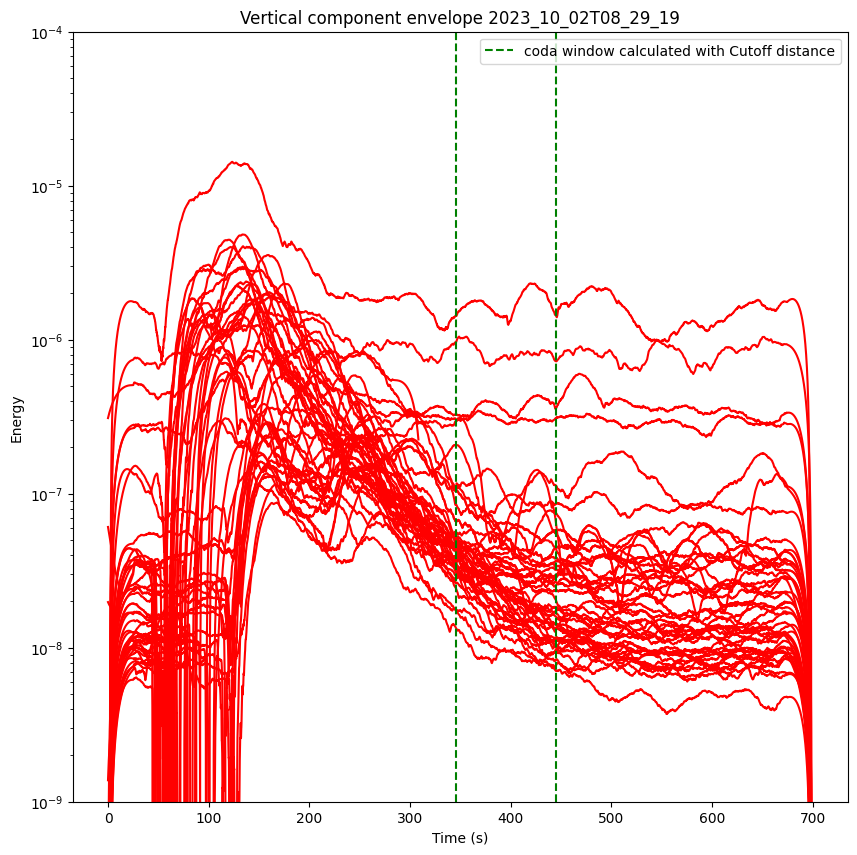

In [10]:
plot_filtered_envelopes = smooth_plot_envelope(time_string,50,filtered_stream,tmincoda_dist=tcoda_test,tmaxcoda_dist=tcoda_test+100)

NameError: name 'idx_reference' is not defined

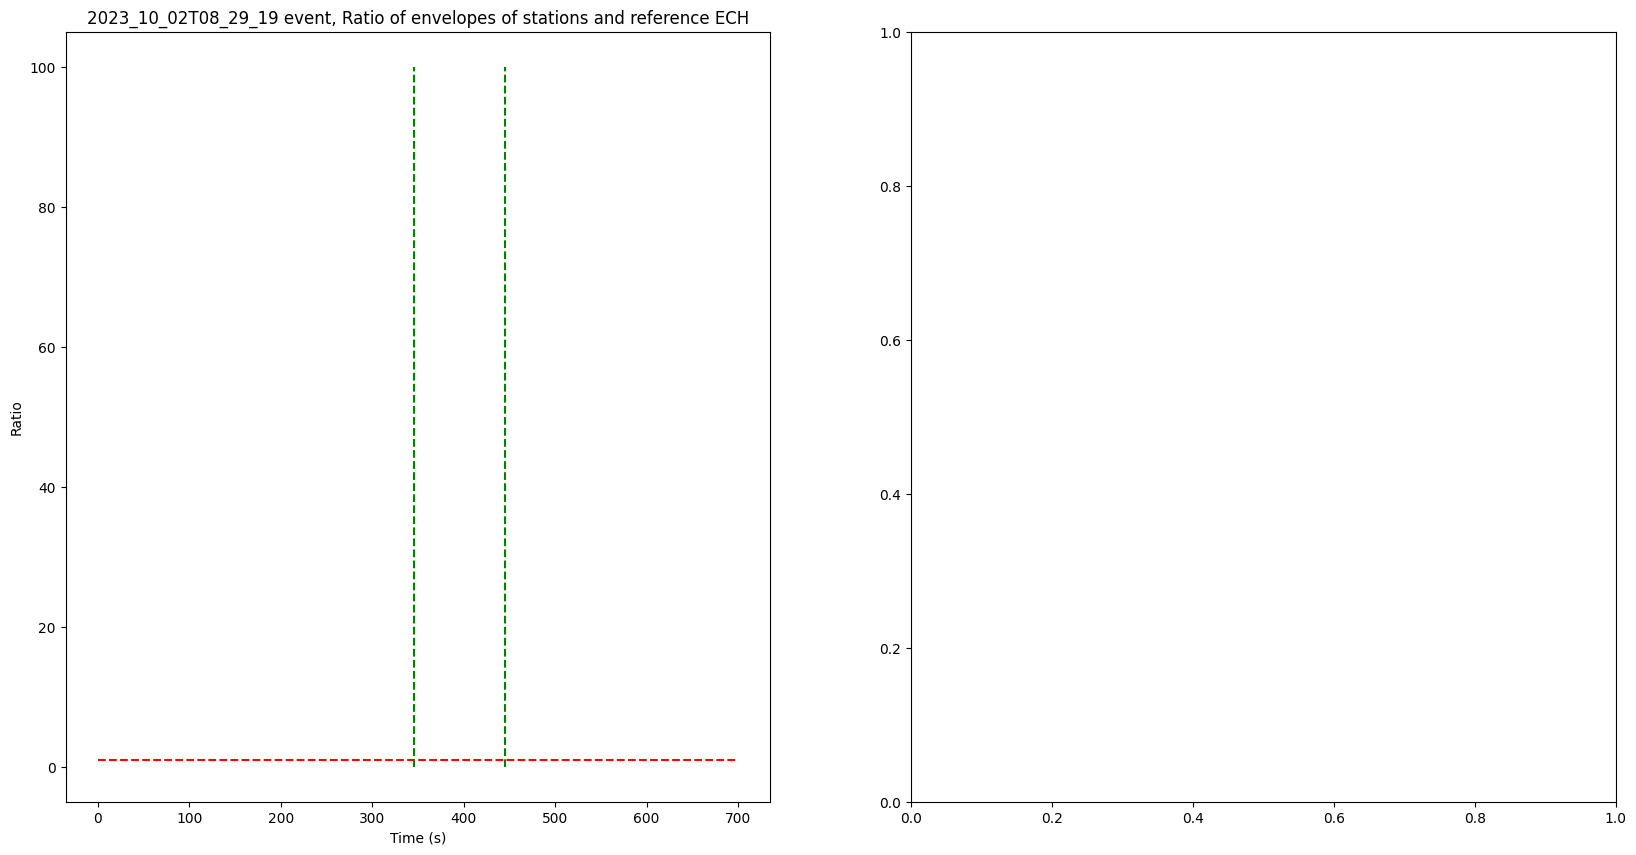

In [11]:
stationref = 'ECH'
testing = [(randint(1, len(filtered_stream))) for i in range(20)]
tcoda_cutoff = tcoda_test
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].set_title(f"{time_string} event, Ratio of envelopes of stations and reference {stationref}")
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Ratio')
axes[0].hlines(1, xmin=0, xmax=700, linestyles="--", colors='r')
axes[0].vlines(tcoda_cutoff, ymax=1e2, ymin=1e-3, label='coda window calculated with cutoff distance', colors='g', linestyles='--')
axes[0].vlines(tcoda_cutoff + 100, ymax=1e2, ymin=1e-3, colors='g', linestyles='--')

for trace_idx in testing:
    trace = filtered_stream[trace_idx]
    axes[0].semilogy(np.arange(0, 700, 0.01), savgol_filter(np.divide(resample(trace.data, 70000), resample(st_envelope[idx_reference].data, 70000)), 5000, 3))

axes[0].legend()

axes[1].set_title(f"{time_string} event, Ratio of envelopes of stations and reference {stationref} (Filtered by SNR=2)")
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Ratio')
axes[1].hlines(1, xmin=0, xmax=700, linestyles="--", colors='r')
axes[1].vlines(tcoda_cutoff, ymax=1e2, ymin=1e-3, label='coda window calculated with cutoff distance', colors='g', linestyles='--')
axes[1].vlines(tcoda_cutoff + 100, ymax=1e2, ymin=1e-3, colors='g', linestyles='--')

for trace_idx in testing:
    station = filtered_stream[trace_idx].stats.station
    if envelopes_amps[station]['snr_coda'] > 2 and envelopes_amps[station]['snr_coda_end'] > 2:
        trace = filtered_stream[trace_idx]
        axes[1].semilogy(np.arange(0, 700, 0.01), savgol_filter(np.divide(resample(trace.data, 70000), resample(st_envelope[idx_reference].data, 70000)), 5000, 3))
    else:
        print(f"Station {station} has coda SNR below 2")

axes[1].legend()

plt.tight_layout()
plt.show()

### 7. Find a reference station for each event
In order to do so, we read in in a dictionary all stations, with the structure per event: amplitude, time, magnitude, snr_coda, snr_last_window. Lets check for which stations we have a lot of recorded events over the SNR threshold.

In [38]:
fmin = 2
fmax = 3
amplitudes_dict = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff",fmin=fmin,fmax=fmax, factor=1.1,data_dir='Data1')

Checking file: /home/schreinl/Stage/Data1/2025_02_11T17_42_36/2025_02_11T17_42_36_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_02T08_29_19/2023_10_02T08_29_19_envelope_amps_cuto

Finding here the stations that have recorded the most events with a sufficient SNR, and check how many interlapping events they have with our main reference station ECH.


In [39]:
station_event_counts = {}
station_snr_counts = {}

reference_station = 'ECH'
total_events = len(amplitudes_dict[reference_station])

for station, entries in amplitudes_dict.items():
    #print(station)
    event_count = 0
    snr_count = 0
    for entry in entries:
        if entry is not None:
            event_count += 1
            if entry['snr_coda'] > 1.5 and entry['snr_last_window'] > 1.5:
                snr_count += 1
    #print(event_count, snr_count)
    station_event_counts[station] = event_count
    station_snr_counts[station] = snr_count

most_recorded_station = max(station_event_counts, key=station_event_counts.get)
most_recorded_events = station_event_counts[most_recorded_station]

most_snr_station = max(station_snr_counts, key=station_snr_counts.get)
most_snr_events = station_snr_counts[most_snr_station]

print(f"Station with the most recorded events: {most_recorded_station} ({most_recorded_events} events) out of {total_events} events")
print(f"Station with the most recorded events with SNR coda and window SNR above 2: {most_snr_station} ({most_snr_events} events)")

stations_with_sufficient_snr = [(station, count) for station, count in station_snr_counts.items() if count > 20]
good_stations = [station for station, count in station_snr_counts.items() if count > 50]
#for now define 10 random stations that can be used as reference stations out of stations that have a high coverage
print(stations_with_sufficient_snr)
print(len(good_stations))

Station with the most recorded events: SLE (135 events) out of 136 events
Station with the most recorded events with SNR coda and window SNR above 2: KHC (86 events)
[('BANN', 31), ('BOUC', 29), ('CALF', 46), ('CHMF', 47), ('CIEL', 23), ('CLF', 50), ('COLF', 30), ('DOU', 50), ('ENAUX', 25), ('ESCA', 35), ('FILF', 25), ('FNEB', 33), ('FRNF', 25), ('HRSF', 24), ('ISO', 45), ('LBL', 26), ('LEUC', 22), ('OG35', 40), ('OGAG', 28), ('OGCB', 24), ('OGCC', 21), ('OGDI', 38), ('OGMY', 23), ('OGRV', 24), ('OGSA', 28), ('OGSI', 31), ('OGVG', 33), ('PLDF', 26), ('RIVEL', 35), ('RONF', 33), ('RSL', 54), ('RUSF', 41), ('SAOF', 44), ('SJAF', 36), ('SMPL', 24), ('SPIF', 27), ('SURF', 39), ('TRBF', 26), ('TRIGF', 25), ('TURF', 25), ('VERF', 24), ('WLS', 52), ('ECH', 76), ('SSB', 63), ('AVM', 23), ('AVP', 26), ('AVR', 22), ('LOR', 45), ('ORIF', 33), ('MEM', 39), ('RCHB', 22), ('HGN', 37), ('ABTA', 64), ('ARSA', 51), ('CSNA', 83), ('DAVA', 66), ('FETA', 69), ('KBA', 61), ('LESA', 21), ('MOA', 70), ('MOTA

In [41]:
three_four_Hz = ['MLS', 'ECH', 'LOR', 'CSNA', 'CONA', 'HASLI', 'SENIN', 'BOURR', 'DAVOX', 'BNALP', 'MOA', 'KHC', 'FUORN', 'BFO']
zerofive_onefive_Hz = good_stations


missing_items = [item for item in three_four_Hz if item not in zerofive_onefive_Hz]
print(missing_items)

['MLS', 'LOR']


Good reference stations for frequency range 3-4Hz would be ['MLS', 'ECH', 'LOR', 'CSNA', 'CONA', 'HASLI', 'SENIN', 'BOURR', 'DAVOX', 'BNALP', 'MOA', 'KHC', 'FUORN', 'BFO']

In [42]:
reference_stations = ['FNEB', 'MLS', 'MONQ', 'ECH', 'SSB', 'LOR', 'CSNA', 'CONA', 'BOJS', 'HASLI', 'SENIN', 'BOURR', 'SLE', 'GIMEL', 'DAVOX', 'FIESA', 'BNALP', 'FUSIO', 'BFO', 'ATE', 'KBA', 'MOA', 'CADS', 'JAVS', 'ROBS', 'VISS', 'VOJS', 'KHC', 'FETA', 'FUORN', 'A084A']
reference_stations = best_bet
for station in reference_stations:
    if station == "ECH":
        continue
    ech_amplitudes = [amp for amp in amplitudes_dict["ECH"] if amp is not None and amp['snr_coda'] > 2 and amp['snr_last_window'] > 2]
    ref_amplitudes = [amp for amp in amplitudes_dict[station] if amp is not None and amp['snr_coda'] > 2 and amp['snr_last_window'] > 2]
    
    ech_times = set(amp['time'] for amp in ech_amplitudes)
    ref_times = set(amp['time'] for amp in ref_amplitudes)
    
    common_times = ech_times.intersection(ref_times)
    
    print(f"Station {station} and ECH have {len(common_times)} events recorded simultaneously with sufficient SNR")

Station MLS and ECH have 24 events recorded simultaneously with sufficient SNR
Station GRA1 and ECH have 34 events recorded simultaneously with sufficient SNR
Station SSB and ECH have 41 events recorded simultaneously with sufficient SNR
Station BFO and ECH have 57 events recorded simultaneously with sufficient SNR
Station LOR and ECH have 29 events recorded simultaneously with sufficient SNR
Station SENIN and ECH have 52 events recorded simultaneously with sufficient SNR
Station HASLI and ECH have 49 events recorded simultaneously with sufficient SNR
Station BOURR and ECH have 46 events recorded simultaneously with sufficient SNR
Station BNALP and ECH have 47 events recorded simultaneously with sufficient SNR
Station DAVOX and ECH have 48 events recorded simultaneously with sufficient SNR
Station FUORN and ECH have 45 events recorded simultaneously with sufficient SNR
Station MOA and ECH have 44 events recorded simultaneously with sufficient SNR
Station CONA and ECH have 50 events rec

In [43]:
reference_stations = ['MLS', 'ECH', 'LOR', 'CSNA', 'CONA', 'HASLI', 'SENIN', 'BOURR', 'DAVOX', 'BNALP', 'MOA', 'KHC', 'FUORN']
reference_stations = ['FNEB', 'MLS', 'MONQ', 'ECH', 'SSB', 'LOR', 'CSNA', 'CONA', 'BOJS', 'HASLI', 'SENIN', 'BOURR', 'SLE', 'GIMEL', 'DAVOX', 'FIESA', 'BNALP', 'FUSIO', 'BFO', 'ATE', 'KBA', 'MOA', 'CADS', 'JAVS', 'ROBS', 'VISS', 'VOJS', 'KHC', 'FETA', 'FUORN', 'A084A']
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

good_stations = best_bet
reference_stations = good_stations
reference_stations.append('BFO')
reference_stations.append('MLS')
reference_stations = best_bet
clients = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC', 'BGR']
origin = [47, 9]
zoom = 5
carte = folium.Map(location=origin, zoom_start=zoom)

stations_snr_dict = dict(station_snr_counts)
stations_coordinates = {}

# Function to get station inventory from a client
def get_inventory(client_name, stations):
    client = Client(client_name)
    try:
        inventory = client.get_stations(network="*", station=",".join(stations), level="station")
        return inventory
    except Exception as e:
        print(f"Error fetching data from {client_name}: {e}")
        return None

# Loop through each datacenter and fetch station information
for client_name in clients:
    inventory = get_inventory(client_name, reference_stations)
    if inventory:
        for network in inventory:
            for station in network:
                lat = station.latitude
                lon = station.longitude
                name = station.code
                valid_points = stations_snr_dict.get(name, 0)
                infos = f"{name} ({lat}, {lon}), {valid_points}"
                folium.CircleMarker(
                    location=[lat, lon],
                    tooltip=infos,
                    radius=4
                ).add_to(carte)
                stations_coordinates[name] = (lat, lon)

carte


Error fetching data from GEOFON: No data available for request.
HTTP Status code: 204
Detailed response of server:


Error fetching data from ICGC: No data available for request.
HTTP Status code: 204
Detailed response of server:




Possible good combination of reference stations:
['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO']

136


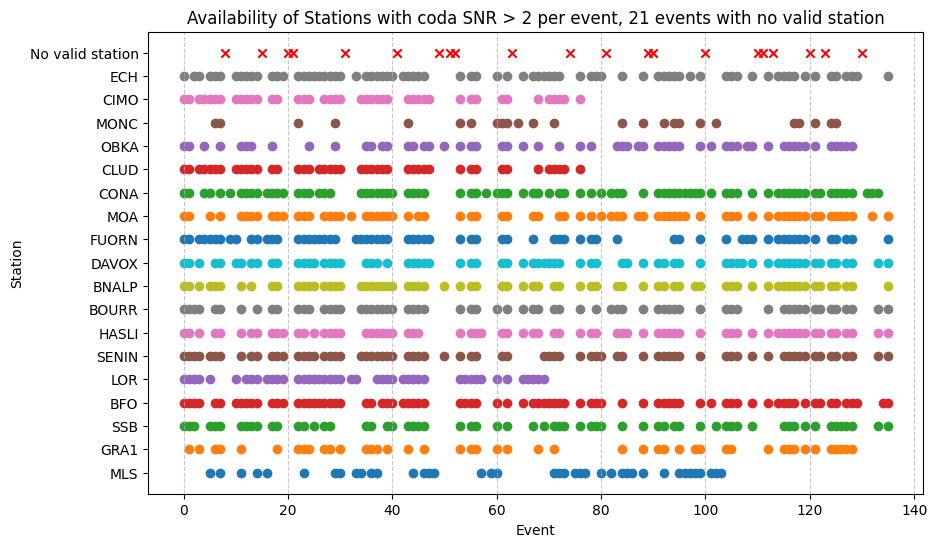

In [44]:
stations_to_plot = ["SSB", "ECH", "FOURG","AJAC", "MLS", "RESF", "ASQU", "MURB","ZCCA","AQU", "PII"]
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']
stations_to_plot = best_bet
station2 = "ECH"
counter = 0
events = range(len(amplitudes_dict[station2]))
print(len(amplitudes_dict[station2]))

plt.figure(figsize=(10, 6))

for i, station in enumerate(stations_to_plot):
    values = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[station]], dtype=np.float64)
    values = np.where(values == None, np.nan, values)
    event_indices = [event for event, value in enumerate(values) if not np.isnan(value)]
    count = len(event_indices)
    plt.scatter(event_indices, [i] * len(event_indices), label=f"{station}({count})", marker='o')

for event in events:
    if all(np.isnan([amplitudes_dict[station][event]['amplitude'] if amplitudes_dict[station][event] is not None and amplitudes_dict[station][event].get('snr_coda', 0) > 1.5 else np.nan for station in stations_to_plot])):
        counter += 1
        plt.scatter(event, len(stations_to_plot), color='red', marker='x', label='No valid station' if event == 0 else "")

plt.xlabel("Event")
plt.ylabel("Station")
plt.yticks(range(len(stations_to_plot) + 1), stations_to_plot + ['No valid station'])
plt.title(f"Availability of Stations with coda SNR > 2 per event, {counter} events with no valid station")
#plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


In [45]:
low_snr_events = []
eq_list = catalogue
for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i]) - 25
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    
    file_path = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt"
    if not os.path.exists(file_path):
        continue
    
    with open(file_path, "r") as file:
        amp_dict = json.load(file)
    
    all_below_threshold = True
    for station in good_stations:
        if station in amp_dict and amp_dict[station].get("snr_coda", 0) > 1.5:
            all_below_threshold = False
            break
    
    if all_below_threshold:
        low_snr_events.append(i)

filtered_eq_list = eq_list.iloc[low_snr_events].reset_index(drop=True)
print(len(filtered_eq_list))
carte = folium.Map([45, 7], zoom_start=5)

for _, row in filtered_eq_list.iterrows():
    infos = f"{row['time']} ({row['latitude']}, {row['longitude']}) {row['mag']} m"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        tooltip=infos,
        fill=True,
        fill_opacity=1.0,
        radius=4,
    ).add_to(carte)

carte

7


Checking file: /home/schreinl/Stage/Data1/2025_02_11T17_42_36/2025_02_11T17_42_36_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_02T08_29_19/2023_10_02

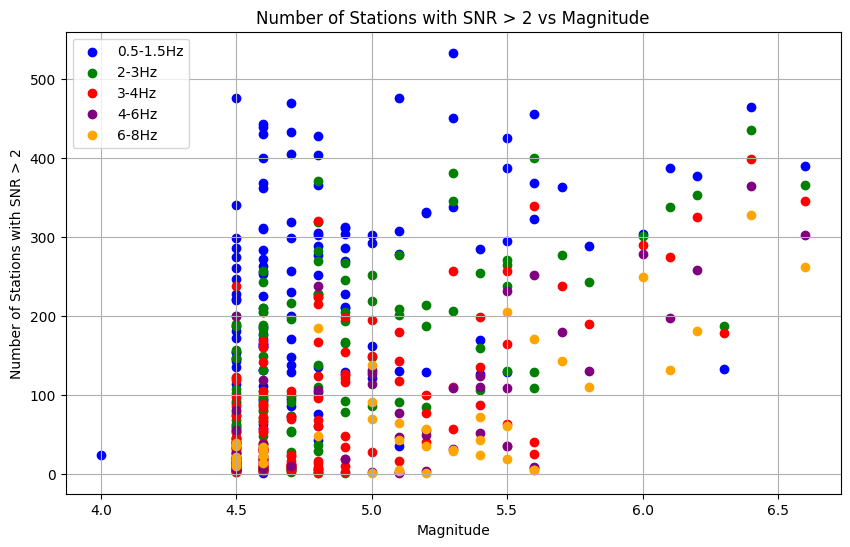

In [17]:
fmin = [0.5, 2, 3, 4, 6]
fmax = [1.5, 3, 4, 6, 8]
colors = ['blue', 'green', 'red', 'purple', 'orange']

plt.figure(figsize=(10, 6))

for i in range(len(fmin)):
    amplitudes_dict = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", fmin=fmin[i], fmax=fmax[i], factor=1.1, data_dir='Data1')

    event_station_counts = {}
    event_magnitudes = {}

    for station, entries in amplitudes_dict.items():
        for entry in entries:
            if entry is not None:
                event_time = entry['time']
                snr_coda = entry.get('snr_coda', 0)
                snr_last_window = entry.get('snr_last_window', 0)
                if snr_coda > 1.5 and snr_last_window > 1.5:
                    if event_time not in event_station_counts:
                        event_station_counts[event_time] = 0
                        event_magnitudes[event_time] = entry['magnitude']
                    event_station_counts[event_time] += 1

    event_times = list(event_station_counts.keys())
    station_counts = list(event_station_counts.values())
    magnitudes = [event_magnitudes[time] for time in event_times]

    plt.scatter(magnitudes, station_counts, c=colors[i], marker='o', label=f'{fmin[i]}-{fmax[i]}Hz')
    print(fmin[i], len(station_counts))
plt.xlabel('Magnitude')
plt.legend()
plt.ylabel('Number of Stations with SNR > 2')
plt.title('Number of Stations with SNR > 2 vs Magnitude')
plt.grid(True)
plt.show()


In [47]:
station_counts = {}

for station, entries in amplitudes_dict.items():
    count = 0
    for entry in entries:
        if entry is not None:
            snr_coda = entry.get('snr_coda', 0)
            snr_last_window = entry.get('snr_last_window', 0)
            if snr_coda > 1.5 and snr_last_window > 1.5:
                count += 1
    station_counts[station] = count

zaehler = 0
for station, counts in station_counts.items():
    if counts <= 1 and counts > 0:
        #print(station)
        zaehler += 1
print(station_counts['A317A'])

8


In [19]:
print(len(amplitudes_dict[station1]))
print(len(amplitudes_dict[station2]))

NameError: name 'station1' is not defined

Shape of denom_amplitudes: (44,)
Shape of counter_amplitudes: (44,)
Mean Ratio (A317A / ECH): 1007539.38842
Standard Deviation: 879792.31332
Median: 853019.28559
Min Ratio: 70828.76446
Max Ratio: 4216112.40632


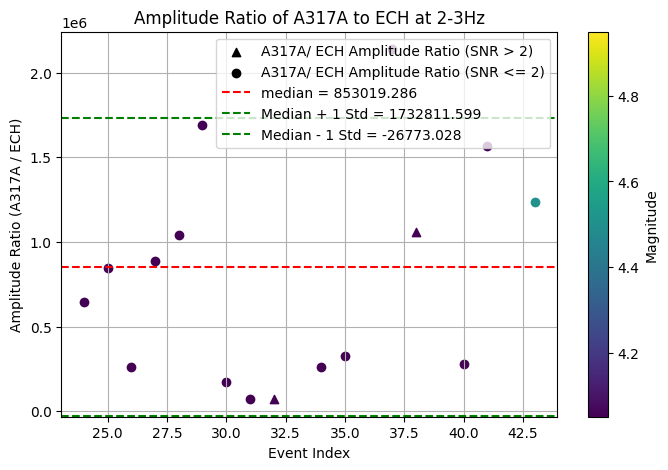

In [49]:
station1 = "A317A" 
station2 = "ECH"

denom_data = [(entry['time'], entry['amplitude']) for entry in amplitudes_dict[station1] if entry is not None]
counter_data = [(entry['time'], entry['amplitude']) for entry in amplitudes_dict[station2] if entry is not None]

denom_dict = dict(denom_data)
counter_dict = dict(counter_data)

common_times = set(denom_dict.keys()) & set(counter_dict.keys())

denom_amplitudes = np.array([denom_dict[t] for t in sorted(common_times)], dtype=np.float64)
counter_amplitudes = np.array([counter_dict[t] for t in sorted(common_times)], dtype=np.float64)
denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)
print(f"Shape of denom_amplitudes: {denom_amplitudes.shape}")
print(f"Shape of counter_amplitudes: {counter_amplitudes.shape}")

ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
valid_ratios = ratio[~np.isnan(ratio)]
mean_ratio = np.nanmean(valid_ratios)
std_ratio = np.nanstd(valid_ratios)
median_ratio = np.nanmedian(valid_ratios)
min_ratio = np.nanmin(valid_ratios)
max_ratio = np.nanmax(valid_ratios)

magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
magnitudes = np.where(magnitudes == None, np.nan, magnitudes)

print(f"Mean Ratio ({station1} / {station2}): {mean_ratio:.5f}")
print(f"Standard Deviation: {std_ratio:.5f}")
print(f"Median: {median_ratio:.5f}")
print(f"Min Ratio: {min_ratio:.5f}")
print(f"Max Ratio: {max_ratio:.5f}")

plt.figure(figsize=(8, 5))
plt.scatter([], [], c='k', marker="^", label=f"{station1}/ {station2} Amplitude Ratio (SNR > 2)")
plt.scatter([], [], c='k', marker="o", label=f"{station1}/ {station2} Amplitude Ratio (SNR <= 2)")

for i, (r, mag) in enumerate(zip(ratio, magnitudes)):
    if not np.isnan(r):
        entry = amplitudes_dict[station1][i]
        if entry is not None:
            snr_coda = entry.get('snr_coda', None)
            if snr_coda is not None and snr_coda > 1.5:
                plt.scatter(i, r, c=mag, cmap='viridis', marker="^")
            else:
                plt.scatter(i, r, c=mag, cmap='viridis', marker="o")


plt.colorbar(label='Magnitude')
plt.axhline(median_ratio, color="r", linestyle="--", label=f"median = {median_ratio:.3f}")
plt.axhline(median_ratio + std_ratio, color="g", linestyle="--", label=f"Median + 1 Std = {median_ratio + std_ratio:.3f}")
plt.axhline(median_ratio - std_ratio, color="g", linestyle="--", label=f"Median - 1 Std = {median_ratio - std_ratio:.3f}")

plt.xlabel("Event Index")
plt.ylabel(f"Amplitude Ratio ({station1} / {station2})")
plt.title(f"Amplitude Ratio of {station1} to {station2} at {fmin}-{fmax}Hz")
plt.legend()
plt.grid(True)
plt.show()





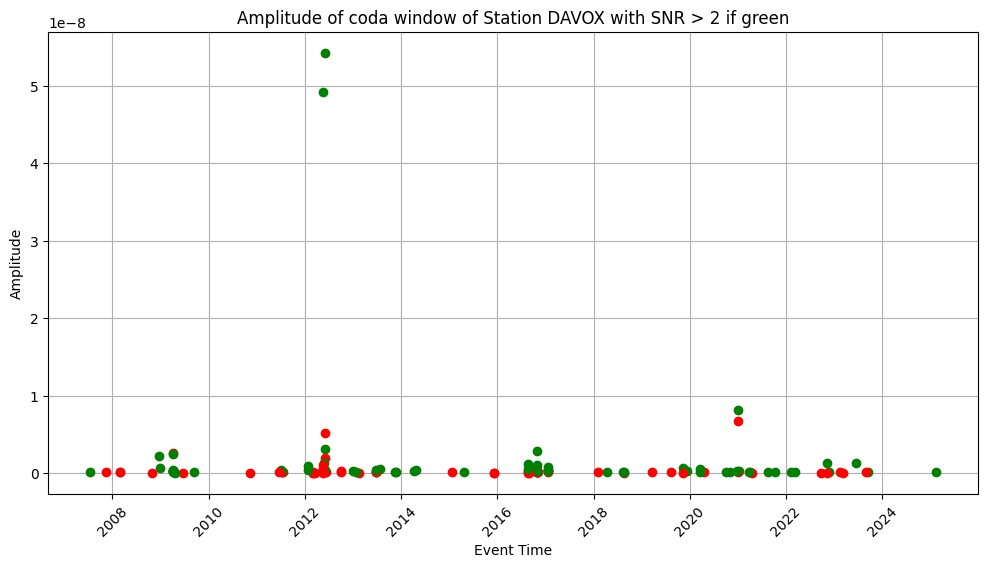

In [51]:
stationcheck = "DAVOX"
from datetime import datetime
ech_amplitudes = [entry['amplitude'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
snr_coda_values = [entry['snr_coda'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
event_times = [entry['time'] if entry is not None else 'None' for entry in amplitudes_dict['ECH']]
valid_indices = [i for i, time in enumerate(event_times) if time != 'None']
valid_times = [event_times[i] for i in valid_indices]
valid_amplitudes = [ech_amplitudes[i] for i in valid_indices]
valid_snr_coda = [snr_coda_values[i] for i in valid_indices]
valid_times = [datetime.strptime(time, '%Y_%m_%dT%H_%M_%S') for time in valid_times]

plt.figure(figsize=(12, 6))
for time, amplitude, snr_coda in zip(valid_times, valid_amplitudes, valid_snr_coda):
    if snr_coda is not None:
        color = 'green' if snr_coda > 1.5 else 'red'
        plt.plot(time, amplitude, 'o', color=color)
#plt.text(0.5, 0.5, 'Green: SNR > 2', color='green')
#plt.text(0.5, 0.5, 'Red: SNR <= 2', color='red')
plt.xlabel('Event Time')
plt.ylabel('Amplitude')
plt.title(f'Amplitude of coda window of Station {stationcheck} with SNR > 2 if green')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Now we calculate the median of the ratio of ECH to each reference station. This value is now integral for the further removal of the site effect.

In [22]:
def calculate_site_term(reference_stations,fmin=0.5,fmax=1.5,factor=1.1,data_dir='Data1',event_file='/home/schreinl/Stage/Data/eq_4_france.csv'):
    amplitudes_dict = create_coda_amplitude_dict(event_file, codawindow="cutoff",fmin=fmin,fmax=fmax, factor=1.1,data_dir='Data1')

In [28]:
#reference_stations = ['FNEB', 'MLS', 'MONQ', 'ECH', 'SSB', 'LOR', 'CSNA', 'CONA', 'BOJS', 'HASLI', 'SENIN', 'BOURR', 'SLE', 'GIMEL', 'DAVOX', 'FIESA', 'BNALP', 'FUSIO', 'BFO', 'ATE', 'KBA', 'MOA', 'CADS', 'JAVS', 'ROBS', 'VISS', 'VOJS', 'KHC', 'FETA', 'FUORN', 'A084A']
#reference_stations = good_station
reference_stations = best_bet
ratios_dict = {}

for station in reference_stations:
    if station == "ECH":
        continue
    
    ech_amplitudes = [amp for amp in amplitudes_dict["ECH"] if amp is not None and amp['snr_coda'] > 2 and amp['snr_last_window'] > 2]
    ref_amplitudes = [amp for amp in amplitudes_dict[station] if amp is not None and amp['snr_coda'] > 2 and amp['snr_last_window'] > 2]
    
    ech_times = set(amp['time'] for amp in ech_amplitudes)
    ref_times = set(amp['time'] for amp in ref_amplitudes)
    
    common_times = ech_times.intersection(ref_times)
    
    ratios = []
    for time in common_times:
        ech_amp = next(amp['amplitude'] for amp in ech_amplitudes if amp['time'] == time)
        ref_amp = next(amp['amplitude'] for amp in ref_amplitudes if amp['time'] == time)
        ratio = ech_amp / ref_amp
        ratios.append(ratio)
    
    ratios_dict[f"{station}"] = ratios

print(ratios_dict)
ref_median_dict = {key: np.median(value) for key, value in ratios_dict.items() if value}


{'MLS': [1.1245416747403414, 1.180188402126737, 2.4279391587987558, 0.9519086236678979, 1.5855151983748097, 1.1624206062259743, 1.415455415840851, 4.597409941191157, 9.395621564579342, 1.2120499558200764, 2.739629903277838, 9.102410571520268, 1.1313397388579085, 1.6638818946078824, 1.9361195424427375, 1.1374839765753038, 1.2271226985828116, 0.898736399710238, 2.4377734795957475, 0.8629769510526824, 2.4914162721753477, 1.5359977488001737, 1.1846731239396462, 5.717223675804419], 'GRA1': [0.3607452296345275, 0.3365397031836803, 0.38362199882307635, 0.32652743708859894, 0.39545991955903376, 0.41564158410976404, 0.435004713435084, 0.6700320977506735, 0.40725675847400505, 0.28122742216255314, 0.7862615597276535, 0.4150987280724745, 0.42030871031837097, 0.4401489443599535, 0.3352108990687581, 0.5517843787743776, 0.4754607964360254, 0.22000649528829436, 0.651865654299851, 0.39719531914794737, 0.4773453152144928, 0.3008389228343665, 0.28544737601608994, 0.19217952282428677, 0.4454360185893237, 

In [24]:
third_snr_coda_value = [entry['snr_coda'] for entry in amplitudes_dict['ECH'] if entry is not None][2]
print(third_snr_coda_value)

0.7147554516603795


### 8. Calculation of Site term

In [29]:
site_effect = {}

num_events = len(next(iter(amplitudes_dict.values())))
reference_stations = best_bet


for event in range(num_events):
    ech_amp = None
    reference_station = None

    if "ECH" in amplitudes_dict and event < len(amplitudes_dict["ECH"]):
        ech_entry = amplitudes_dict["ECH"][event]
        if ech_entry and ech_entry.get("snr_coda", 0) > 2:
            ech_amp = ech_entry["amplitude"]
            reference_station = "ECH"

    if ech_amp is None:
        for ref in reference_stations:
            if ref in amplitudes_dict and event < len(amplitudes_dict[ref]):
                ref_entry = amplitudes_dict[ref][event]
                if ref_entry and ref_entry.get("snr_coda", 0) > 2:
                    ref_amp = ref_entry["amplitude"]
                    ref_median_ratio = ref_median_dict.get(ref, None)
                    
                    if ref_median_ratio is not None:
                        ech_amp = ref_amp * ref_median_ratio 
                        reference_station = ref
                        print(f'used reference station {reference_station}')
                    break 
    if ech_amp is None:
        continue

    for station in amplitudes_dict:
        if event < len(amplitudes_dict[station]): 
            station_entry = amplitudes_dict[station][event]
            if station_entry and station_entry.get("snr_coda", 0) > 2:
                station_amp = station_entry["amplitude"]
                ratio = station_amp / ech_amp 
                magnitude = station_entry["magnitude"]
                latitude = station_entry['latitude']
                longitude = station_entry['longitude']

                if station not in site_effect:
                    site_effect[station] = []
                site_effect[station].append({
                    "ratio": ratio,
                    "time": station_entry["time"],
                    "reference_station": reference_station,
                    "magnitude": magnitude,
                    "latitude" : latitude,
                    "longitude" : longitude
                })

print(site_effect)


used reference station GRA1
used reference station MLS
used reference station MLS
used reference station MOA
used reference station MLS
used reference station LOR
used reference station BFO
used reference station BFO
used reference station LOR
used reference station MLS
used reference station LOR
used reference station MLS
used reference station CONA
used reference station MLS
used reference station SENIN
used reference station LOR
used reference station MLS
used reference station MLS
used reference station MLS
used reference station MLS
used reference station MLS
used reference station CONA
used reference station MOA
used reference station MLS
used reference station CONA
used reference station MLS
used reference station CONA
used reference station MLS
used reference station MLS
used reference station FUORN
used reference station CONA
used reference station SENIN
used reference station SENIN
used reference station SSB
used reference station MOA
used reference station SSB
{'BRGF': [{'ra

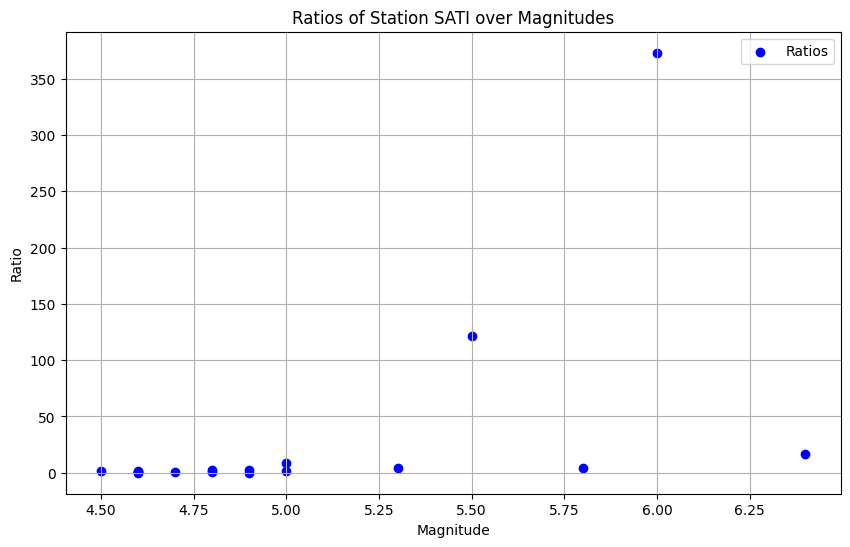

In [88]:

ratios = [entry['ratio'] for entry in site_effect['SATI']]
magnitudes = [entry['magnitude'] for entry in site_effect['SATI']]

plt.figure(figsize=(10, 6))
plt.scatter(magnitudes, ratios, c='blue', marker='o', label='Ratios')

plt.xlabel('Magnitude')
plt.ylabel('Ratio')
plt.title('Ratios of Station SATI over Magnitudes')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt
import matplotlib.cm as cm

stationplot = "DAVOX"
#stationplot = 'A317A'
station_coords = {}
with open('/home/schreinl/Stage/Data1/all_stations_coordinates.txt', 'r') as file:
    next(file)
    for line in file:
        network, station, lat, lon = line.strip().split(',')
        station_coords[station] = (float(lat), float(lon))

mls_coords = station_coords[stationplot]

distances = []
ratios = []
magnitudes = []
for entry in site_effect[stationplot]:
    event_lat = entry['latitude']
    event_lon = entry['longitude']
    ratio = entry['ratio']
    magnitude = entry['magnitude']
    
    distance, _, _ = gps2dist_azimuth(mls_coords[0], mls_coords[1], event_lat, event_lon)
    distance_km = distance / 1000
    
    distances.append(distance_km)
    ratios.append(ratio)
    magnitudes.append(magnitude)

norm = Normalize(vmin=min(magnitudes), vmax=max(magnitudes))
cmap = cm.viridis

plt.figure(figsize=(10, 6))
sc = plt.scatter(distances, ratios, c=magnitudes, cmap=cmap, norm=norm, marker='o', label='Ratios')
plt.colorbar(sc, label='Magnitude')
plt.xlabel('Distance (km)')
plt.ylabel('Ratio')
plt.title(f'Ratios of Station {stationplot} over Distance to Events')
plt.legend()
plt.grid(True)
plt.show()

IndexError: invalid index to scalar variable.

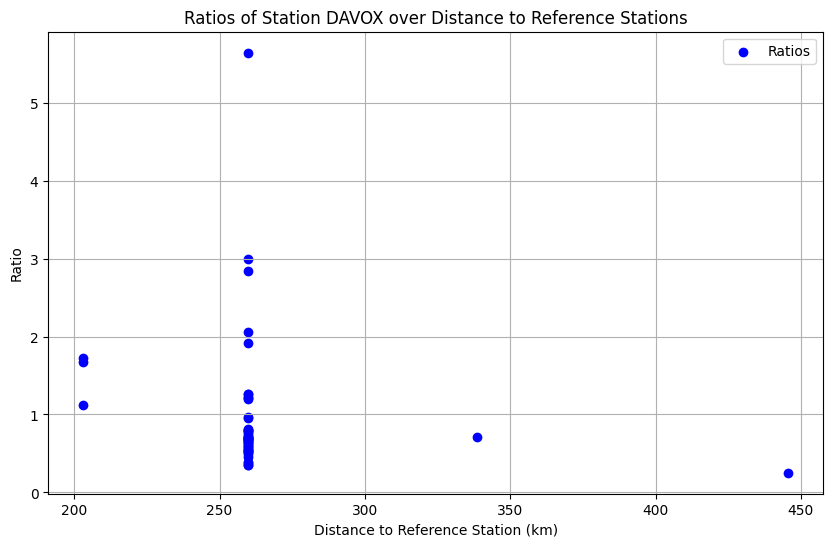

In [90]:
stationplot = "DAVOX"
station_coords = {}
with open('/home/schreinl/Stage/Data1/all_stations_coordinates.txt', 'r') as file:
    next(file)
    for line in file:
        network, station, lat, lon = line.strip().split(',')
        station_coords[station] = (float(lat), float(lon))

mls_coords = station_coords[stationplot]

distances = []
ratios = []
for entry in site_effect[stationplot]:
    ref_station = entry['reference_station']
    ref_coords = station_coords.get(ref_station)
    if ref_coords:
        ratio = entry['ratio']
        distance, _, _ = gps2dist_azimuth(mls_coords[0], mls_coords[1], ref_coords[0], ref_coords[1])
        distance_km = distance / 1000
        
        distances.append(distance_km)
        ratios.append(ratio)

plt.figure(figsize=(10, 6))
plt.scatter(distances, ratios, c='blue', marker='o', label='Ratios')
plt.xlabel('Distance to Reference Station (km)')
plt.ylabel('Ratio')
plt.title(f'Ratios of Station {stationplot} over Distance to Reference Stations')
plt.legend()
plt.grid(True)
plt.show()

Initial: Median = 1.5596058825076426, Std = 89.88434442649961, Events = 17
After Filtering: Median = 1.4341705477544604, Std = 29.01457945357109, Events = 16


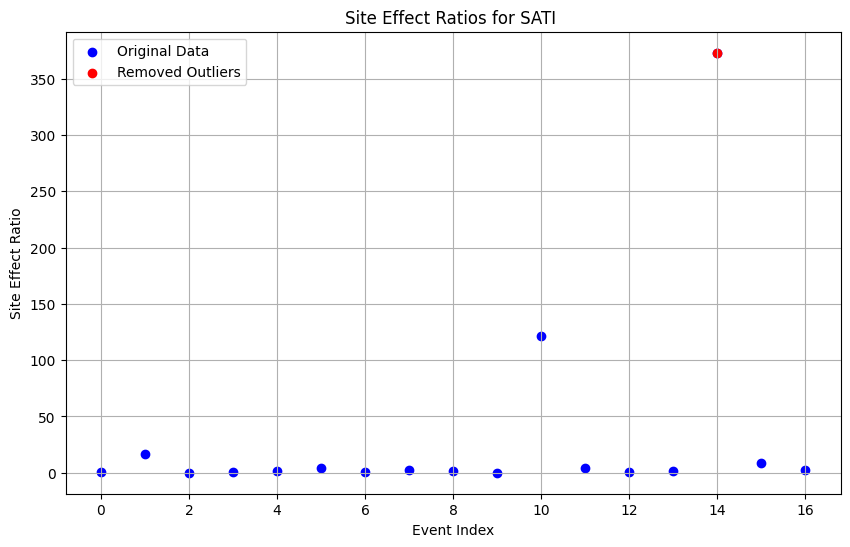

In [92]:

station = 'GEPF'
station = 'A084A'
station = 'GORS'
station = 'DAVOX'
station = 'SATI'

ratios = np.array([entry['ratio'] for entry in site_effect[station]]) 

median = np.median(ratios)
std = np.std(ratios)
num_points = len(ratios)
print(f'Initial: Median = {median}, Std = {std}, Events = {num_points}')

Z = (ratios - np.mean(ratios)) / np.std(ratios)

outlier_indices = np.where(Z > 1.3)[0]

ratios_new = np.delete(ratios, outlier_indices)

median_new = np.median(ratios_new)
std_new = np.std(ratios_new)
num_points_new = len(ratios_new)
print(f'After Filtering: Median = {median_new}, Std = {std_new}, Events = {num_points_new}')

plt.figure(figsize=(10, 6))

plt.scatter(range(len(ratios)), ratios, color="blue", label="Original Data")

plt.scatter(outlier_indices, ratios[outlier_indices], color="red", label="Removed Outliers")

plt.xlabel("Event Index")
plt.ylabel("Site Effect Ratio")
plt.title(f"Site Effect Ratios for {station} ")
plt.legend()
plt.grid(True)
plt.show()


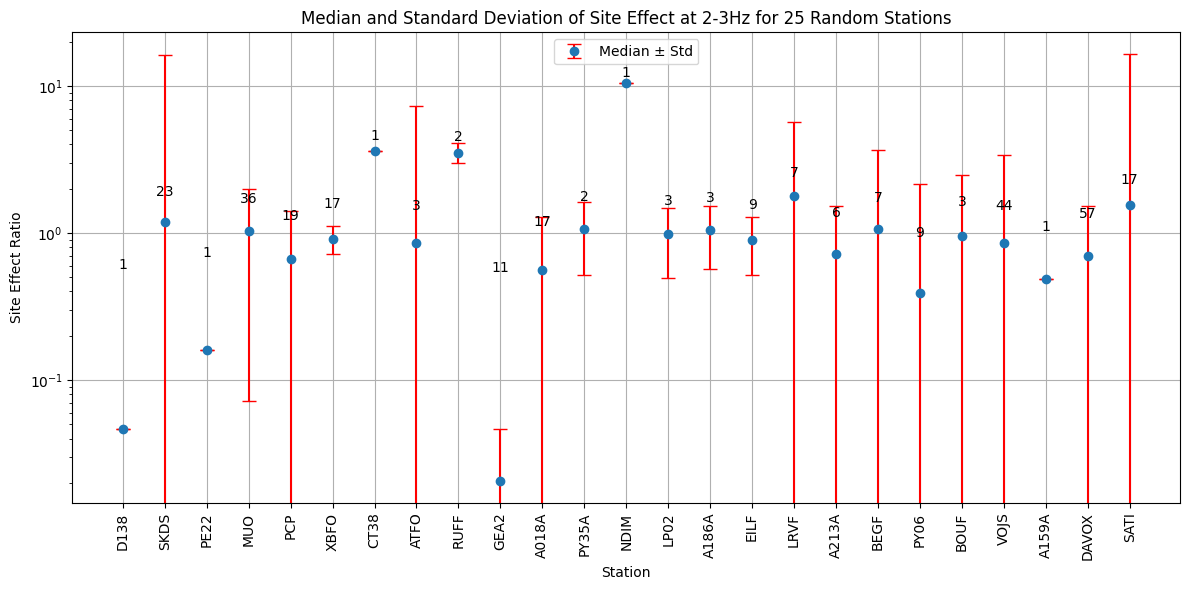

In [ ]:
random_stations = random.sample(list(site_effect.keys()), 23)
random_stations.append('DAVOX')
random_stations.append('SATI')

medians = []
stds = []
num_points = []
for station in random_stations:
    ratios = [entry['ratio'] for entry in site_effect[station]]
    medians.append(np.median(ratios))
    stds.append(np.std(ratios))
    num_points.append(len(ratios))

ylim_min, ylim_max = 0, 15
clipped_medians = np.clip(medians, ylim_min, ylim_max)
clipped_stds = np.clip(stds, 0, ylim_max - ylim_min)

plt.figure(figsize=(12, 6))
plt.errorbar(random_stations, clipped_medians, yerr=clipped_stds, fmt='o', ecolor='r', capsize=5, label='Median ± Std')
plt.xlabel('Station')
plt.ylabel('Site Effect Ratio')
plt.title(f'Median and Standard Deviation of Site Effect at {fmin}-{fmax}Hz for 25 Random Stations')
plt.xticks(rotation=90)
#plt.ylim([ylim_min, ylim_max])
plt.yscale('log')
plt.legend()
plt.grid(True)

for i, (station, median, num) in enumerate(zip(random_stations, clipped_medians, num_points)):
    plt.text(i, median + 0.5, str(num), ha='center', va='bottom')

plt.tight_layout()
plt.show()

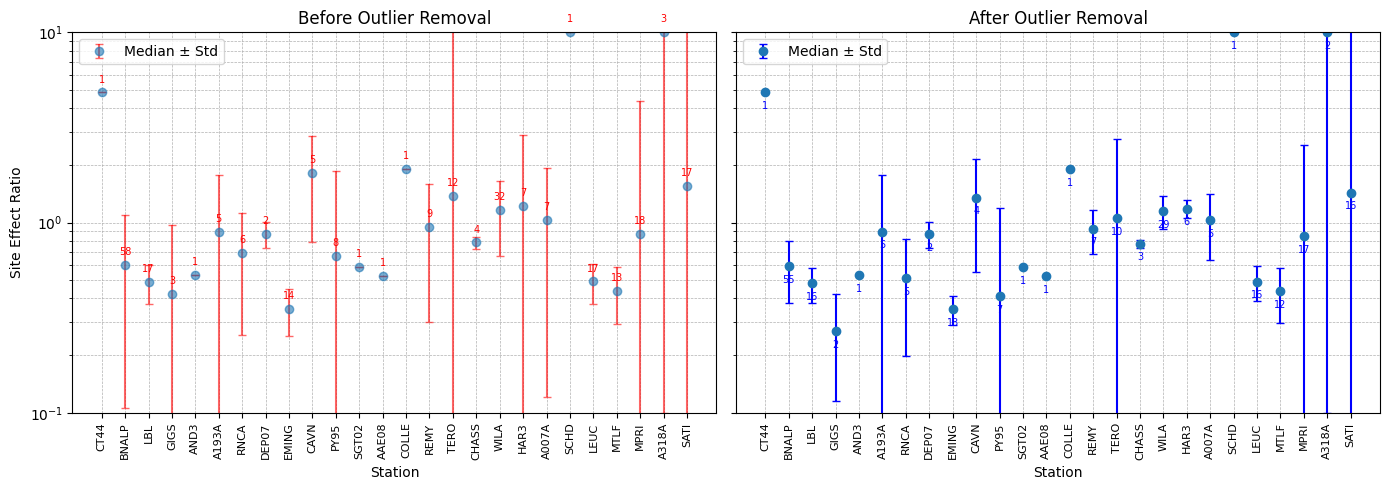

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import random

random_stations = random.sample(list(site_effect.keys()), 25)
random_stations.append('SATI')

medians = []
stds = []
num_points = []
medians_filtered = []
stds_filtered = []
num_points_filtered = []

for station in random_stations:
    ratios = np.array([entry['ratio'] for entry in site_effect[station]])
    
    medians.append(np.median(ratios))
    stds.append(np.std(ratios))
    num_points.append(len(ratios))
    
    Z = (ratios - np.mean(ratios)) / np.std(ratios)
    outlier_indices = np.where(Z > 1.3)[0]
    ratios_filtered = np.delete(ratios, outlier_indices)

    medians_filtered.append(np.median(ratios_filtered))
    stds_filtered.append(np.std(ratios_filtered))
    num_points_filtered.append(len(ratios_filtered))

ylim_min, ylim_max = 0.1, 10  

clipped_medians = np.clip(medians, ylim_min, ylim_max)
clipped_stds = np.clip(stds, 0, ylim_max - ylim_min)
clipped_medians_filtered = np.clip(medians_filtered, ylim_min, ylim_max)
clipped_stds_filtered = np.clip(stds_filtered, 0, ylim_max - ylim_min)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].errorbar(random_stations, clipped_medians, yerr=clipped_stds, fmt='o', ecolor='r', capsize=3, label='Median ± Std', alpha=0.6)
axes[0].set_title('Before Outlier Removal')
axes[0].set_xticklabels(random_stations, rotation=90, fontsize=8)
axes[0].set_yscale('log')
axes[0].set_ylim([ylim_min, ylim_max])
axes[0].set_xlabel('Station')
axes[0].set_ylabel('Site Effect Ratio')
axes[0].legend()
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

for i, (median, num) in enumerate(zip(clipped_medians, num_points)):
    axes[0].text(i, median * 1.1, str(num), ha='center', va='bottom', color='red', fontsize=7)

axes[1].errorbar(random_stations, clipped_medians_filtered, yerr=clipped_stds_filtered, fmt='o', ecolor='b', capsize=3, label='Median ± Std')
axes[1].set_title('After Outlier Removal')
axes[1].set_xticklabels(random_stations, rotation=90, fontsize=8)
axes[1].set_yscale('log')
axes[1].set_ylim([ylim_min, ylim_max])
axes[1].set_xlabel('Station')
axes[1].legend()
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

for i, (median_filtered, num_filtered) in enumerate(zip(clipped_medians_filtered, num_points_filtered)):
    axes[1].text(i, median_filtered * 0.9, str(num_filtered), ha='center', va='top', color='blue', fontsize=7)

plt.tight_layout()
plt.show()


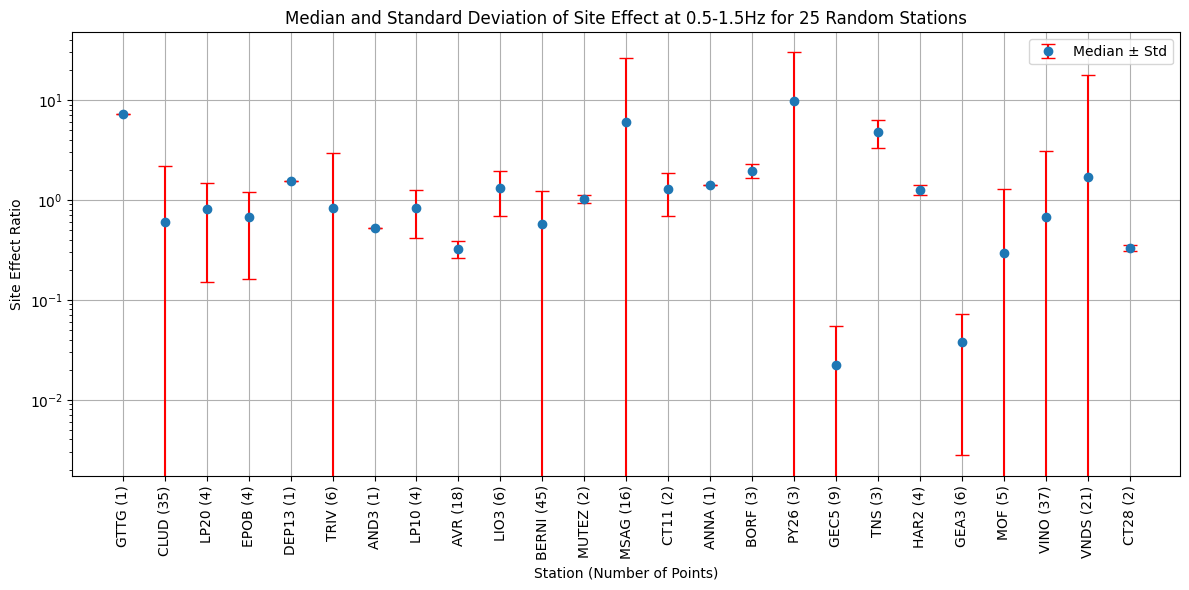

In [31]:

random_stations = random.sample(list(site_effect.keys()), 25)

medians = []
stds = []
num_points = []

for station in random_stations:
    ratios = np.array([entry['ratio'] for entry in site_effect[station]])
    medians.append(np.median(ratios))
    stds.append(np.std(ratios))
    num_points.append(len(ratios))

ylim_min, ylim_max = 0, 20

clipped_medians = np.clip(medians, ylim_min, ylim_max)
clipped_stds = np.clip(stds, 0, ylim_max - ylim_min)

x_labels = [f"{station} ({num})" for station, num in zip(random_stations, num_points)]

plt.figure(figsize=(12, 6))
plt.errorbar(x_labels, clipped_medians, yerr=clipped_stds, fmt='o', ecolor='r', capsize=5, label='Median ± Std')
plt.xlabel('Station (Number of Points)')
plt.ylabel('Site Effect Ratio')
plt.title('Median and Standard Deviation of Site Effect at 0.5-1.5Hz for 25 Random Stations')
plt.xticks(rotation=90)
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


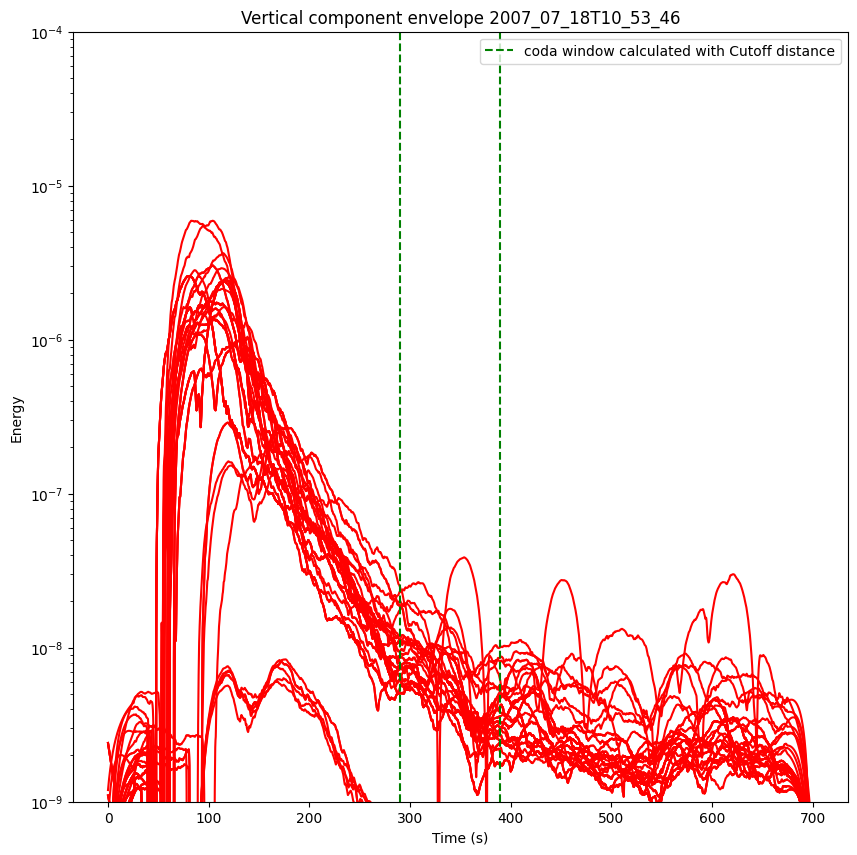

In [46]:
plot_filtered_smoothed = smooth_plot_envelope(time_string, 50,st_double_filt,
                    tmincoda_dist=tcoda_test, tmaxcoda_dist=tcoda_test+100, savefig=False)

### 9. Following all the steps for different frequency bands


In [ ]:
from urllib.error import URLError
import os
import warnings
warnings.filterwarnings("ignore")

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC']
directory = '/home/schreinl/Stage/Data1/'
distmin = 1.9
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
eq_list = catalogue_5
eq_list = first_row = catalogue_5.iloc[0]
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,3,4,6,8]
fmax = [1.5,3,4,6,8,10]


start = UTCDateTime(eq_list["time"]) -25
end = start + 700
eq_lon = float(eq_list["longitude"])
eq_lat = float(eq_list["latitude"])
    
time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
try:
    st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
except (URLError, FDSNNoDataException) as e:
    print(f"Failed to download data for event {e}")
for f in range(len(fmin)):
    print(f"Processing for frequency band {fmin[f]} - {fmax[f]} Hz")
    envelope_file = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_envelope_{codawindow}_fac_{factor}_{fmin[f]}_{fmax[f]}Hz_stream.mseed"
    amplitude_file = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_envelope_amps_{codawindow}_fac_{factor}_{fmin[f]}_{fmax[f]}Hzdict.txt"
    
    if os.path.exists(envelope_file) and os.path.exists(amplitude_file):
        print(f"Files for event already exist. Skipping...")
        continue
    
    

    st_plot_filt_all = st_all.copy()
    #fmin = fmin 
    #fmax = fmax
    st_plot_filt_all.filter("bandpass", freqmin=fmin[f], freqmax=fmax[f])

    st_envelope = obspy.Stream()
    smallest = 7000
    for tr in st_plot_filt_all:
        data_envelope = envelope_calculator(tr.data)
        npts = tr.stats.npts
        if npts >= smallest:
            samprate = tr.stats.sampling_rate
            t = np.arange(0, npts / samprate, 1 / samprate)
            tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
            st_envelope.append(tr_envelope)

    snr_threshold = 3.5
    eq_start = start

    filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_test, filtered_st, stations_with_amps, amp_plot = SNR_all(
        stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min, vLg_max, vPg_min, vPg_max, tminCoda, tmaxCoda,
        Dtmin_Noise, Dtmax_Noise, eq_start, eq_lat, eq_lon, snr_threshold=snr_threshold, plot_SNR=False, plot_amps=True, wavecode="Lg_Coda", dB=True, codawindow=codawindow, factor=factor)



    with open(f"/home/schreinl/Stage/Data1/Dicts/{time_string}_{snr_threshold}_thresh_{fmin[f]}_{fmax[f]}Hz_dict.txt", "w") as file:
        json.dump(distance_dict, file, indent=4)
    
    # Save stations_with_amps to a file
    with open(f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_{snr_threshold}_thresh_{fmin[f]}_{fmax[f]}Hz_stations_with_amps.txt", "w") as ampls:
        json.dump(stations_with_amps.tolist(), ampls, indent=4)

        # Save filtered stations with their corresponding SNR
    with open(f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_{snr_threshold}_thresh_{fmin[f]}_{fmax[f]}Hz_filtered_stations_SNR.txt", "w") as snrfile:
        json.dump(filtered_stations_with_SNR.tolist(), snrfile, indent=4)

        # Save the stations with SNR, unfiltered
    with open(f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_{fmin[f]}_{fmax[f]}Hz_unfiltered_stations_SNR.txt", "w") as unsnrfile:
        json.dump(stations_with_SNR.tolist(), unsnrfile, indent=4)
    amplitudes_full = calc_amps(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test, tcoda_test+100, Dtmin_Noise, Dtmax_Noise, eq_start)
    amplitudes_small = calc_amps(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min,vPg_max, tcoda_test+80, tcoda_test+100, Dtmin_Noise, Dtmax_Noise, eq_start)
    SNR_dict = select_ratio_dict("Coda_Noise", amplitudes_full)
    SNR_dict_small = select_ratio_dict("Coda_Noise", amplitudes_small)
    envelopes_amps, st_smooth = envelopes_routine1(time_string, st_envelope, coda_dist_start=tcoda_test, coda_dist_end=tcoda_test + 100, plotting=False, method='cutoff', snr=SNR_dict, snr_window=SNR_dict_small)
    st_smooth.write(envelope_file, format="MSEED")

    with open(amplitude_file, "w") as ampls:
        json.dump(envelopes_amps, ampls, indent=4)

    filtered_station_names = set(row[1] for row in filtered_stations_with_SNR)
    filtered_smooth_stream = obspy.Stream()
    filtered_stream = obspy.Stream()
    for trace in st_smooth:
        if trace.stats.station in filtered_station_names:
            filtered_smooth_stream.append(trace)
    for trace in st_envelope:
        if trace.stats.station in filtered_station_names:
            filtered_stream.append(trace)
    
    #plot_filtered_smoothed = smooth_plot_envelope(time_string, 50, filtered_stream, method='cutoff distance', tmincoda_dist=tcoda_test, tmaxcoda_dist=tcoda_test + 100, plotshow=False, savefig=True)

### 10. Site effect per station over frequencies

In [32]:
fmin = [0.5, 2, 3, 4, 6]
fmax = [1.5, 3, 4, 6, 8]

site_effect_medians = {}

for i in range(len(fmin)):
    amplitudes_dict = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/eq_4_france.csv', codawindow="cutoff", fmin=fmin[i], fmax=fmax[i], factor=1.1, data_dir='Data1')
    
    site_effect = {}

    num_events = len(next(iter(amplitudes_dict.values())))
    reference_stations = best_bet

    for event in range(num_events):
        ech_amp = None
        reference_station = None

        if "ECH" in amplitudes_dict and event < len(amplitudes_dict["ECH"]):
            ech_entry = amplitudes_dict["ECH"][event]
            if ech_entry and ech_entry.get("snr_coda", 0) > 2:
                ech_amp = ech_entry["amplitude"]
                reference_station = "ECH"

        if ech_amp is None:
            for ref in reference_stations:
                if ref in amplitudes_dict and event < len(amplitudes_dict[ref]):
                    ref_entry = amplitudes_dict[ref][event]
                    if ref_entry and ref_entry.get("snr_coda", 0) > 2:
                        ref_amp = ref_entry["amplitude"]
                        ref_median_ratio = ref_median_dict.get(ref, None)
                        
                        if ref_median_ratio is not None:
                            ech_amp = ref_amp * ref_median_ratio 
                            reference_station = ref
                        break 
        if ech_amp is None:
            continue

        for station in amplitudes_dict:
            if event < len(amplitudes_dict[station]): 
                station_entry = amplitudes_dict[station][event]
                if station_entry and station_entry.get("snr_coda", 0) > 2:
                    station_amp = station_entry["amplitude"]
                    ratio = station_amp / ech_amp 

                    if station not in site_effect:
                        site_effect[station] = []
                    site_effect[station].append(ratio)
    
    site_effect_median_std = {station: (np.median(ratios), np.std(ratios)) for station, ratios in site_effect.items()}
    site_effect_medians[f"{fmin[i]}-{fmax[i]}Hz"] = site_effect_median_std

print(site_effect_medians)


Checking file: /home/schreinl/Stage/Data1/2025_01_12T13_51_15/2025_01_12T13_51_15_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_06_04T00_34_07/2024_06_04T00_34_07_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_27T21_19_12/2024_03_27T21_19_12_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_17T00_23_04/2024_02_17T00_23_04_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_09T12_05_57/2024_02_09T12_05_57_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_11_21T05_51_40/2023_11_21T05_51_40_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_28T15_28_57/2023_10_28T15_28_57_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_09_18T03_09_49/2023_09_18T03_09_49_envelope

In [33]:
fmin = [0.5, 2, 3, 4, 6]
fmax = [1.5, 3, 4, 6, 8]

site_effect_medians = {}

for i in range(len(fmin)):
    amplitudes_dict = create_coda_amplitude_dict(
        event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', 
        codawindow="cutoff", 
        fmin=fmin[i], fmax=fmax[i], factor=1.1, data_dir='Data1'
    )
    
    site_effect = {}
    num_events = len(next(iter(amplitudes_dict.values())))
    reference_stations = best_bet 

    for event in range(num_events):
        ech_amp = None
        reference_station = None

        if "ECH" in amplitudes_dict and event < len(amplitudes_dict["ECH"]):
            ech_entry = amplitudes_dict["ECH"][event]
            if ech_entry and ech_entry.get("snr_coda", 0) > 2:
                ech_amp = ech_entry["amplitude"]
                reference_station = "ECH"

        if ech_amp is None:
            for ref in reference_stations:
                if ref in amplitudes_dict and event < len(amplitudes_dict[ref]):
                    ref_entry = amplitudes_dict[ref][event]
                    if ref_entry and ref_entry.get("snr_coda", 0) > 2:
                        ref_amp = ref_entry["amplitude"]
                        ref_median_ratio = ref_median_dict.get(ref, None)
                        
                        if ref_median_ratio is not None:
                            ech_amp = ref_amp * ref_median_ratio 
                            reference_station = ref
                        break 
        if ech_amp is None:
            continue

        for station in amplitudes_dict:
            if event < len(amplitudes_dict[station]): 
                station_entry = amplitudes_dict[station][event]
                if station_entry and station_entry.get("snr_coda", 0) > 2:
                    station_amp = station_entry["amplitude"]
                    ratio = station_amp / ech_amp 

                    if station not in site_effect:
                        site_effect[station] = []
                    site_effect[station].append(ratio)

    site_effect_median_std = {}
    for station, ratios in site_effect.items():
        ratios = np.array(ratios)

        Z = (ratios - np.mean(ratios)) / np.std(ratios)
        outlier_indices = np.where(Z > 1.5)[0]

        ratios_filtered = np.delete(ratios, outlier_indices)

        median_before = np.median(ratios)
        std_before = np.std(ratios)
        median_after = np.median(ratios_filtered)
        std_after = np.std(ratios_filtered)

        site_effect_median_std[station] = {
            "median_before": median_before,
            "std_before": std_before,
            "num_points_before": len(ratios),
            "median_after": median_after,
            "std_after": std_after,
            "num_points_after": len(ratios_filtered)
        }

    site_effect_medians[f"{fmin[i]}-{fmax[i]}Hz"] = site_effect_median_std

print(site_effect_medians)





Checking file: /home/schreinl/Stage/Data1/2025_02_11T17_42_36/2025_02_11T17_42_36_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_02T08_29_19/2023_10_02

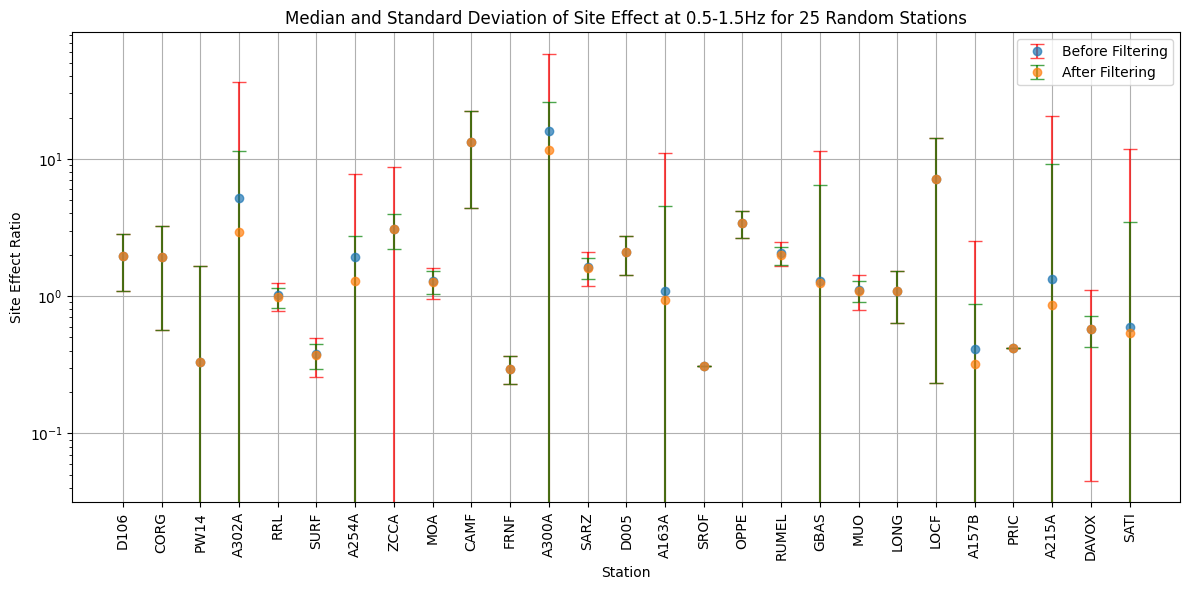

In [92]:

site_effects_0_5_1_5Hz = site_effect_medians['0.5-1.5Hz']

random_stations = random.sample(list(site_effects_0_5_1_5Hz.keys()), 25)
random_stations.append('DAVOX')
random_stations.append('SATI')

medians_before = [site_effects_0_5_1_5Hz[station]['median_before'] for station in random_stations]
stds_before = [site_effects_0_5_1_5Hz[station]['std_before'] for station in random_stations]
medians_after = [site_effects_0_5_1_5Hz[station]['median_after'] for station in random_stations]
stds_after = [site_effects_0_5_1_5Hz[station]['std_after'] for station in random_stations]

plt.figure(figsize=(12, 6))

plt.errorbar(random_stations, medians_before, yerr=stds_before, fmt='o', ecolor='r', capsize=5, label='Before Filtering', alpha=0.7)

plt.errorbar(random_stations, medians_after, yerr=stds_after, fmt='o', ecolor='g', capsize=5, label='After Filtering', alpha=0.7)

plt.xlabel('Station')
plt.ylabel('Site Effect Ratio')
plt.title('Median and Standard Deviation of Site Effect at 0.5-1.5Hz for 25 Random Stations')
plt.xticks(rotation=90)
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()



plt.show()

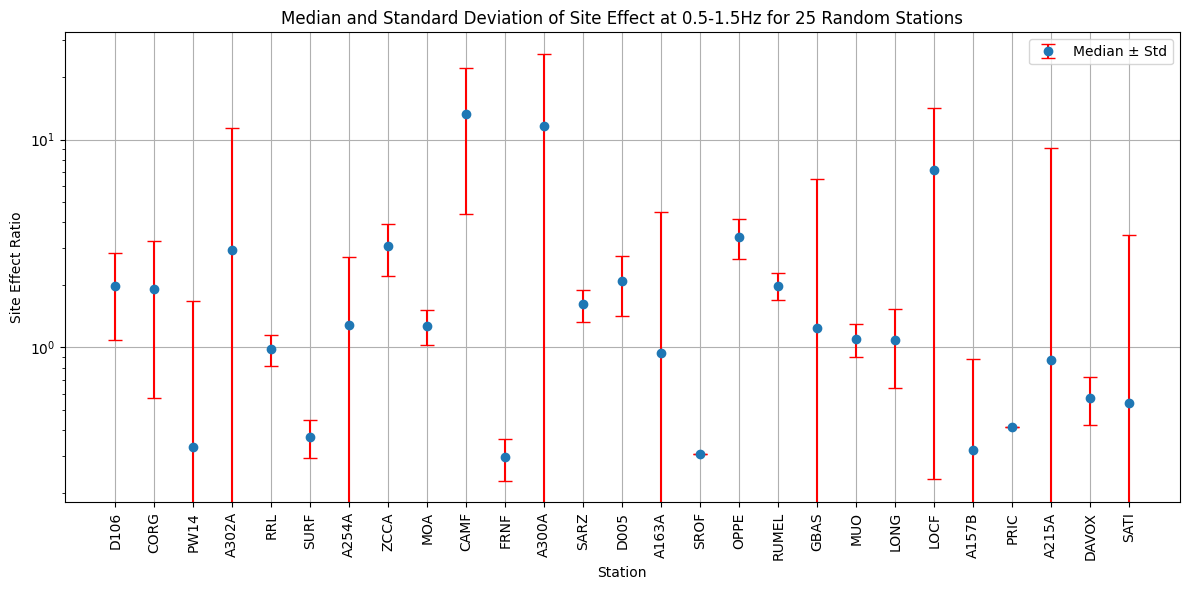

In [93]:

site_effects_0_5_1_5Hz = site_effect_medians['0.5-1.5Hz']
#random_stations = random.sample(list(site_effects_0_5_1_5Hz.keys()), 23)
medians = [site_effects_0_5_1_5Hz[station]['median_after'] for station in random_stations]
stds = [site_effects_0_5_1_5Hz[station]['std_after'] for station in random_stations]
plt.figure(figsize=(12, 6))
plt.errorbar(random_stations, medians, yerr=stds, fmt='o', ecolor='r', capsize=5, label='Median ± Std')
plt.xlabel('Station')
plt.ylabel('Site Effect Ratio')
plt.title('Median and Standard Deviation of Site Effect at 0.5-1.5Hz for 25 Random Stations')
plt.xticks(rotation=90)
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Frequency Ranges: ['0.5-1.5Hz', '2-3Hz', '3-4Hz', '4-6Hz', '6-8Hz']
Medians Before: [6332310.173953264, 713692.7534283798, 554661.8351600369, 137584.1315089982, 29009.316499928478]
Standard Deviations Before: [7072837.884254911, 1174548.6621260908, 374920.4308850964, 131007.62042946293, 0.0]
Medians After: [4407516.352910189, 575219.0534448066, 554661.8351600369, 137584.1315089982, 29009.316499928478]
Standard Deviations After: [4956847.925924404, 458612.9178750947, 374920.4308850964, 131007.62042946293, 0.0]


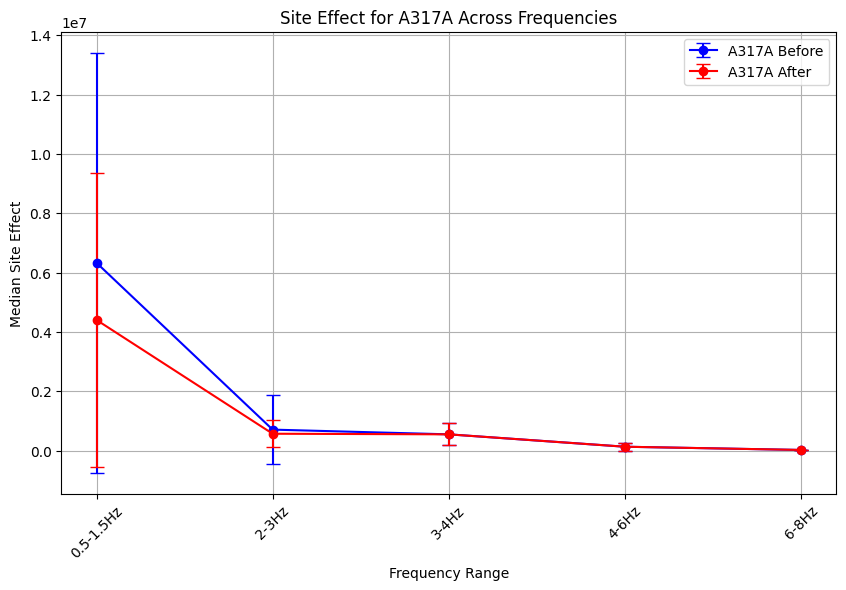

In [35]:
station_name = "MOA"
station_name = 'A317A'

freq_ranges = list(site_effect_medians.keys())
medians_before = []
stds_before = []
medians_after = []
stds_after = []

for freq in freq_ranges:
    if station_name in site_effect_medians[freq]:
        median_before = site_effect_medians[freq][station_name]['median_before']
        std_before = site_effect_medians[freq][station_name]['std_before']
        median_after = site_effect_medians[freq][station_name]['median_after']
        std_after = site_effect_medians[freq][station_name]['std_after']
    else:
        median_before, std_before = np.nan, np.nan
        median_after, std_after = np.nan, np.nan

    medians_before.append(median_before)
    stds_before.append(std_before)
    medians_after.append(median_after)
    stds_after.append(std_after)

print("Frequency Ranges:", freq_ranges)
print("Medians Before:", medians_before)
print("Standard Deviations Before:", stds_before)
print("Medians After:", medians_after)
print("Standard Deviations After:", stds_after)

medians_before = np.array(medians_before)
stds_before = np.array(stds_before)
medians_after = np.array(medians_after)
stds_after = np.array(stds_after)

plt.figure(figsize=(10, 6))
plt.errorbar(freq_ranges, medians_before, yerr=stds_before, fmt='o-', capsize=5, label=f'{station_name} Before', color='b')
plt.errorbar(freq_ranges, medians_after, yerr=stds_after, fmt='o-', capsize=5, label=f'{station_name} After', color='r')
plt.xlabel("Frequency Range")
plt.ylabel("Median Site Effect")
plt.title(f"Site Effect for {station_name} Across Frequencies")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

### 11. Stations with and without site effect measures

In [114]:
import glob

fmin = 2
fmax = 3
amplitudes_dict = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff",fmin=fmin,fmax=fmax, factor=1.1,data_dir='Data1')
station_counts = {}

for station, entries in amplitudes_dict.items():
    count = 0
    for entry in entries:
        if entry is not None:
            snr_coda = entry.get('snr_coda', 0)
            snr_last_window = entry.get('snr_last_window', 0)
            if snr_coda > 1.5 and snr_last_window > 1.5:
                count += 1
    station_counts[station] = count

zaehler = 0
for station, counts in station_counts.items():
    if counts <= 1 and counts > 0:
        #print(station)
        zaehler += 1


event_map = folium.Map(location=[46.2145, -0.7295], zoom_start=5)

data_directory = '/home/schreinl/Stage/Data1/'
metadata_directory = os.path.join(data_directory, "Metadata/")

event_locations = []

for metadata_file in os.listdir(metadata_directory):
    metadata_path = os.path.join(metadata_directory, metadata_file)
    if os.path.isfile(metadata_path):
        try:
            with open(metadata_path, 'r') as file:
                lines = file.readlines()
                lat, lon = None, None
                
                for line in lines:
                    if line.startswith("Latitude:"):
                        lat = float(line.split(":")[1].strip())
                    elif line.startswith("Longitude:"):
                        lon = float(line.split(":")[1].strip())
                
                if lat is not None and lon is not None:
                    event_locations.append((lat, lon))
        except Exception as e:
            print(f"Error reading {metadata_path}: {e}")


plotted_stations = {}

for event_dir in os.listdir(data_directory):
    event_path = os.path.join(data_directory, event_dir)
    if os.path.isdir(event_path):
        file_pattern = os.path.join(event_path, f'*{fmin}_{fmax}Hz_unfiltered_stations_SNR.txt')
        matching_files = glob.glob(file_pattern)
        
        for file_path in matching_files:
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    
                    for station in data:
                        if len(station) >= 4:
                            network = station[0]
                            name = station[1]
                            lat = float(station[2])
                            lon = float(station[3])
                            station_id = (lat, lon)
                            
                            plotted_stations[station_id] = (network, name)

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

print('done reading in')


#stations_coordinates[name] = (lat, lon)


for (lat, lon), (network, name) in plotted_stations.items():
    count = station_counts.get(name, 0)  # Default to 0 if station not found
    color = "green" if count > 0 else "red"
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=6, 
        tooltip=f"{network}.{name} ({lat}, {lon}), Count: {count}",
        color=color,
        fill=True,
        fill_color=color
    ).add_to(event_map)

for name, (lat, lon) in stations_coordinates.items():
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        tooltip=f"{name} ({lat}, {lon}) Reference station",
        color="blue",
        fill=True,
        fill_color=color
    ).add_to(event_map)


output_file = '/home/schreinl/Stage/Data1/all_stations_coordinates.txt'

with open(output_file, 'w') as file:
    file.write("Network,Station,Latitude,Longitude\n")
    for station in stations_all:
        network = station[0]
        name = station[1]
        lat = station[2]
        lon = station[3]
        file.write(f"{network},{name},{lat},{lon}\n")

print(f"All stations written to {output_file}")
event_map


Checking file: /home/schreinl/Stage/Data1/2025_02_11T17_42_36/2025_02_11T17_42_36_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_2_3Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_02T08_29_19/2023_10_02T08_29_19_envelope_amps_cuto

In [64]:
import folium

lat_min, lat_max = 49.4, 49.9
lon_min, lon_max = 11, 12

from obspy.clients.fdsn import Client

client = Client("BGR")
network = "*" 

inventory = client.get_stations(network=network, level="station",minlatitude=lat_min, maxlatitude=lat_max,minlongitude=lon_min,maxlongitude=lon_max)

stations = []
for network in inventory:
    for station in network:
        stations.append({
            "network": network.code,
            "station": station.code,
            "latitude": station.latitude,
            "longitude": station.longitude,
            "elevation": station.elevation
        })


station_map = folium.Map(location=[46.2145, -0.7295], zoom_start=5)

for station in stations:
    folium.Marker(
        location=[station['latitude'], station['longitude']],
        popup=f"{station['network']}.{station['station']}",
        tooltip=f"{station['network']}.{station['station']}"
    ).add_to(station_map)

# Display the map
station_map

### Plot the stations with the colorcode of the Site Effect


In [ ]:
station_counts = {}

for station, entries in amplitudes_dict.items():
    count = 0
    for entry in entries:
        if entry is not None:
            snr_coda = entry.get('snr_coda', 0)
            snr_last_window = entry.get('snr_last_window', 0)
            if snr_coda > 1.5 and snr_last_window > 1.5:
                count += 1
    station_counts[station] = count

zaehler = 0
for station, counts in station_counts.items():
    if counts <= 1 and counts > 0:
        #print(station)
        zaehler += 1

In [ ]:
import glob
import matplotlib.colors as mcolors
from branca.colormap import LinearColormap


fmin = 0.5
fmax = 1.5
event_map = folium.Map(location=[46.2145, -0.7295], zoom_start=5)

data_directory = '/home/schreinl/Stage/Data1/'
metadata_directory = os.path.join(data_directory, "Metadata/")

event_locations = []

for metadata_file in os.listdir(metadata_directory):
    metadata_path = os.path.join(metadata_directory, metadata_file)
    if os.path.isfile(metadata_path):
        try:
            with open(metadata_path, 'r') as file:
                lines = file.readlines()
                lat, lon = None, None
                
                for line in lines:
                    if line.startswith("Latitude:"):
                        lat = float(line.split(":")[1].strip())
                    elif line.startswith("Longitude:"):
                        lon = float(line.split(":")[1].strip())
                
                if lat is not None and lon is not None:
                    event_locations.append((lat, lon))
        except Exception as e:
            print(f"Error reading {metadata_path}: {e}")


plotted_stations = {}

for event_dir in os.listdir(data_directory):
    event_path = os.path.join(data_directory, event_dir)
    if os.path.isdir(event_path):
        file_pattern = os.path.join(event_path, f'*{fmin}_{fmax}Hz_unfiltered_stations_SNR.txt')
        matching_files = glob.glob(file_pattern)
        
        for file_path in matching_files:
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    
                    for station in data:
                        if len(station) >= 4:
                            network = station[0]
                            name = station[1]
                            lat = float(station[2])
                            lon = float(station[3])
                            station_id = (lat, lon)
                            
                            plotted_stations[station_id] = (network, name)

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

print('done reading in')

def color_scale(min_value, max_value, num_steps=100):
    """
    Creates a list of colors based on the get_color function for the range [min_value, max_value].
    """
    return [get_color(value) for value in np.linspace(min_value, max_value, num_steps)]


color_list = color_scale(0.1, 10)

colormap = LinearColormap(color_list, vmin=0.1, vmax=10)

colormap.add_to(event_map)
colormap.caption = f"Median Site Effect ({fmin}-{fmax}Hz)"
for (lat, lon), (network, name) in plotted_stations.items():
    station_medians = site_effect_medians.get(f'{fmin}-{fmax}Hz', {}).get(name, {})
    median_before = station_medians.get('median_after', None)

    if median_before is not None:
        color = get_color(median_before)
        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            tooltip=f"{network}.{name} ({lat}, {lon}), Median: {median_before}",
            color="black",  
            weight=1, 
            fill=True,
            fill_color=color,
            fill_opacity=1
        ).add_to(event_map)

event_map


done reading in


### Improvement of Datapoints using a larger Catalog

In [3]:
catalog_old = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
catalog_old = catalog_old[catalog_old['mag'] >= 4.0].reset_index(drop=True)

catalog_new= pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
catalog_new= catalog_new[catalog_new['mag'] >= 4.0].reset_index(drop=True)

fmin = 0.5
fmax = 1.5
amplitudes_dict_old = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/eq_4_france.csv', codawindow="cutoff",fmin=fmin,fmax=fmax, factor=1.1,data_dir='Data1')
amplitudes_dict_new = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff",fmin=fmin,fmax=fmax, factor=1.1,data_dir='Data1')

Checking file: /home/schreinl/Stage/Data1/2025_01_12T13_51_15/2025_01_12T13_51_15_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_06_04T00_34_07/2024_06_04T00_34_07_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_27T21_19_12/2024_03_27T21_19_12_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_17T00_23_04/2024_02_17T00_23_04_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_09T12_05_57/2024_02_09T12_05_57_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_11_21T05_51_40/2023_11_21T05_51_40_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_28T15_28_57/2023_10_28T15_28_57_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_09_18T03_09_49/2023_09_18T03_09_49_envelope

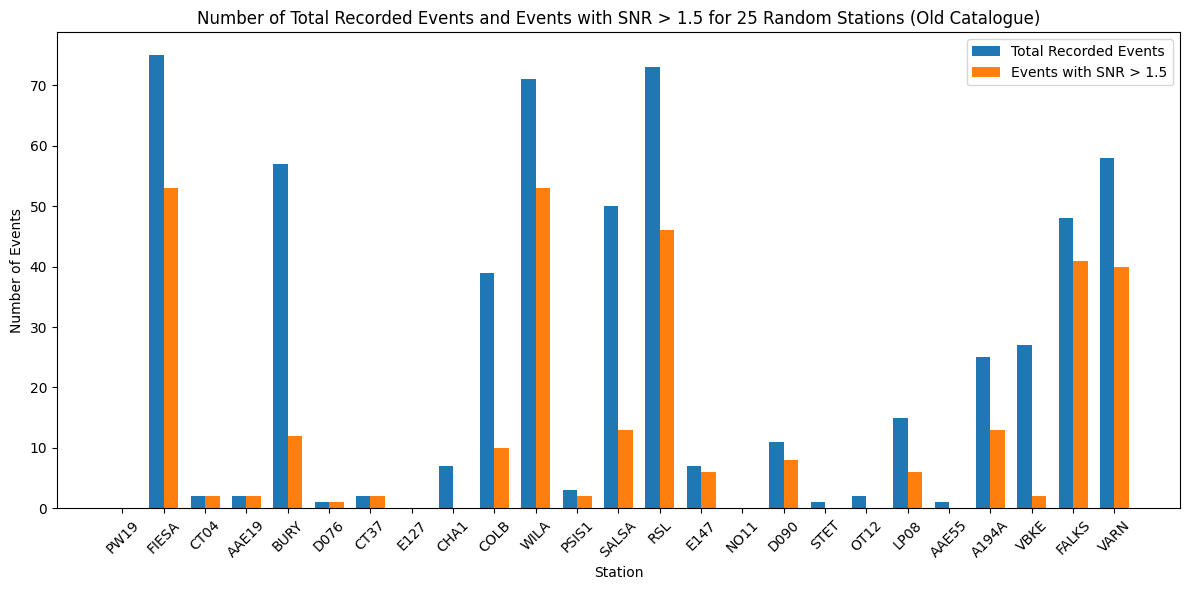

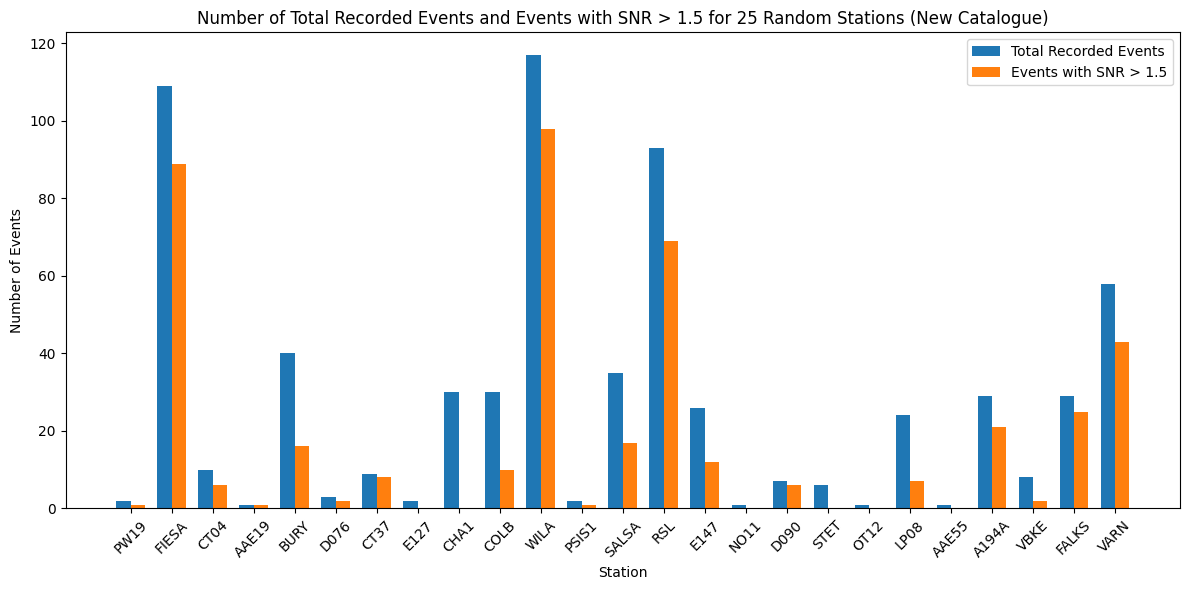

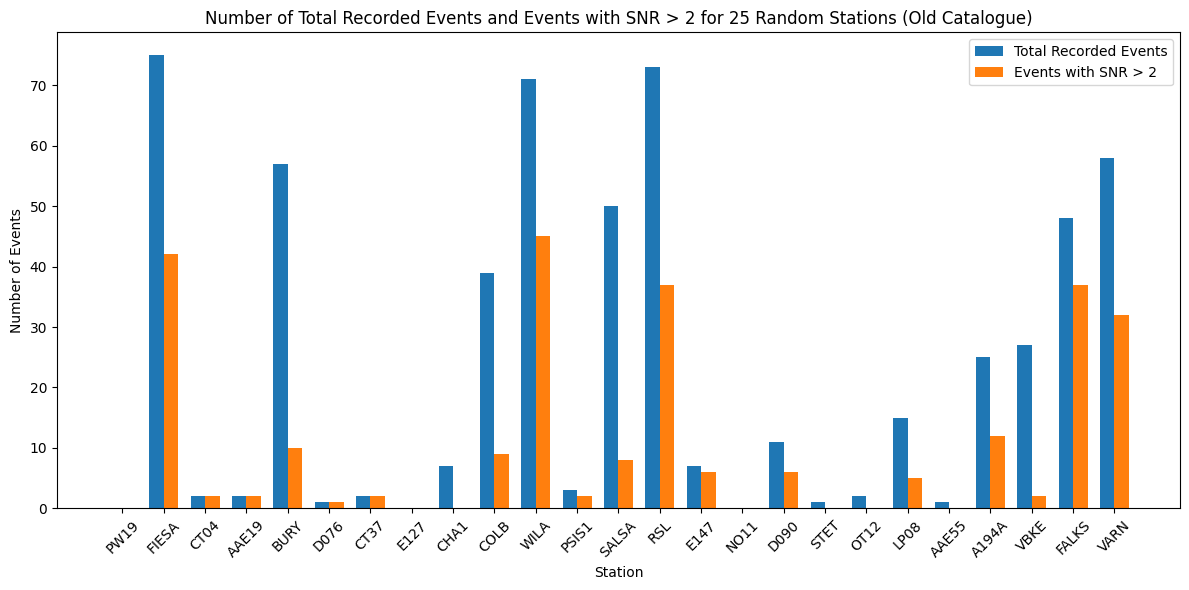

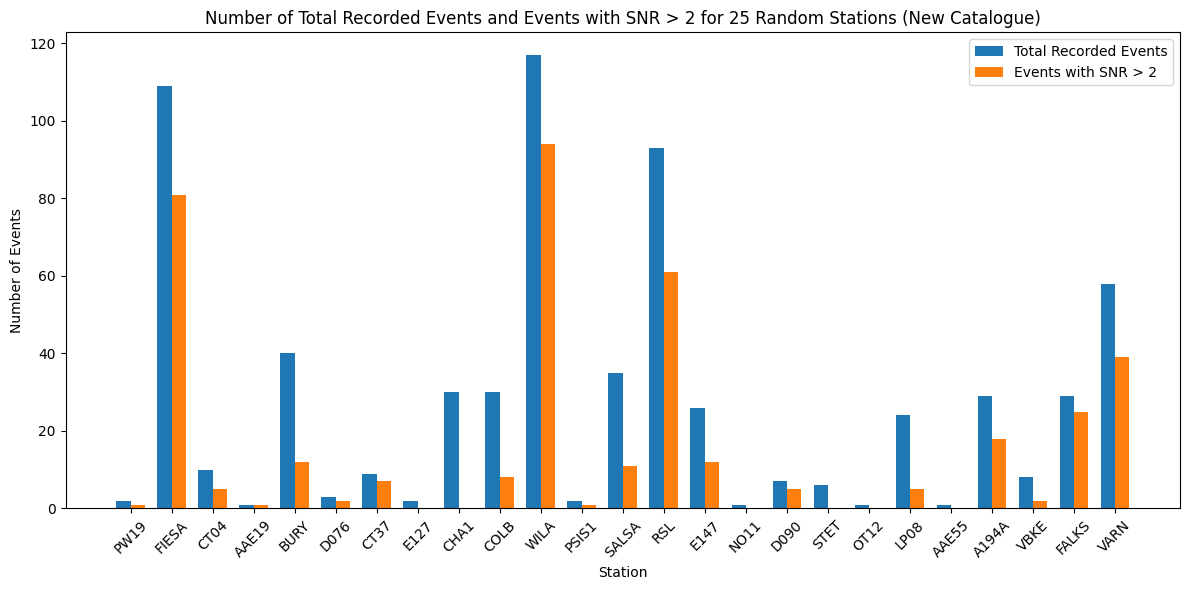

In [ ]:
station_data_old = {}
station_data_new = {}

random_stations = random.sample(list(amplitudes_dict_new.keys()), 25)

# Process old dictionary
for station in random_stations:
    amplitudes = amplitudes_dict_old.get(station, [])
    recorded_count = sum(amp is not None for amp in amplitudes)
    snr_over_1_5 = sum(entry['snr_coda'] > 1.5 if entry is not None and 'snr_coda' in entry else False for entry in amplitudes)
    snr_over_2 = sum(entry['snr_coda'] > 2 if entry is not None and 'snr_coda' in entry else False for entry in amplitudes)
    station_data_old[station] = {
        'recorded_count': recorded_count,
        'snr_over_1_5': snr_over_1_5,
        'snr_over_2': snr_over_2
    }

# Process new dictionary
for station in random_stations:
    amplitudes = amplitudes_dict_new.get(station, [])
    recorded_count = sum(amp is not None for amp in amplitudes)
    snr_over_1_5 = sum(entry['snr_coda'] > 1.5 if entry is not None and 'snr_coda' in entry else False for entry in amplitudes)
    snr_over_2 = sum(entry['snr_coda'] > 2 if entry is not None and 'snr_coda' in entry else False for entry in amplitudes)
    station_data_new[station] = {
        'recorded_count': recorded_count,
        'snr_over_1_5': snr_over_1_5,
        'snr_over_2': snr_over_2
    }

stations = list(station_data_old.keys())
recorded_counts_old = [station_data_old[station]['recorded_count'] for station in stations]
snr_over_1_5_counts_old = [station_data_old[station]['snr_over_1_5'] for station in stations]
snr_over_2_counts_old = [station_data_old[station]['snr_over_2'] for station in stations]

recorded_counts_new = [station_data_new[station]['recorded_count'] for station in stations]
snr_over_1_5_counts_new = [station_data_new[station]['snr_over_1_5'] for station in stations]
snr_over_2_counts_new = [station_data_new[station]['snr_over_2'] for station in stations]

# Plot for old dictionary
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(stations))

plt.bar(index, recorded_counts_old, bar_width, label='Total Recorded Events')
plt.bar([i + bar_width for i in index], snr_over_1_5_counts_old, bar_width, label='Events with SNR > 1.5')

plt.xlabel('Station')
plt.ylabel('Number of Events')
plt.title('Number of Total Recorded Events and Events with SNR > 1.5 for 25 Random Stations (Old Catalogue)')
plt.xticks([i + bar_width / 2 for i in index], stations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(stations))

plt.bar(index, recorded_counts_new, bar_width, label='Total Recorded Events')
plt.bar([i + bar_width for i in index], snr_over_1_5_counts_new, bar_width, label='Events with SNR > 1.5')

plt.xlabel('Station')
plt.ylabel('Number of Events')
plt.title('Number of Total Recorded Events and Events with SNR > 1.5 for 25 Random Stations (New Catalogue)')
plt.xticks([i + bar_width / 2 for i in index], stations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(stations))

plt.bar(index, recorded_counts_old, bar_width, label='Total Recorded Events')
plt.bar([i + bar_width for i in index], snr_over_2_counts_old, bar_width, label='Events with SNR > 2')

plt.xlabel('Station')
plt.ylabel('Number of Events')
plt.title('Number of Total Recorded Events and Events with SNR > 2 for 25 Random Stations (Old Catalogue)')
plt.xticks([i + bar_width / 2 for i in index], stations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(stations))

plt.bar(index, recorded_counts_new, bar_width, label='Total Recorded Events')
plt.bar([i + bar_width for i in index], snr_over_2_counts_new, bar_width, label='Events with SNR > 2')

plt.xlabel('Station')
plt.ylabel('Number of Events')
plt.title('Number of Total Recorded Events and Events with SNR > 2 for 25 Random Stations (New Catalogue)')
plt.xticks([i + bar_width / 2 for i in index], stations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### Coda Q as a Byproduct

In [43]:
eq_list = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
coda_Q_dict = {}
codawindow = 'cutoff'
factor = 1.1
data_dir = 'Data1'
fmin = 0.5
fmax = 1.5

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i]) - 25
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    magnitude = eq_list["mag"][i]
    latitude = eq_list["latitude"][i]
    longitude = eq_list["longitude"][i]
    
    file_path = f"/home/schreinl/Stage/{data_dir}/{time_string}/{time_string}_envelope_amps_{codawindow}_fac_{factor}_{fmin}_{fmax}Hz_dict.txt"
    print(f"Checking file: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"File does not exist: {file_path}")
        continue
    
    try:
        with open(file_path, "r") as file:
            amp_dict = json.load(file)
        
        for station, data in amp_dict.items():
            if station not in coda_Q_dict:
                coda_Q_dict[station] = [None] * i 
            coda_Q_dict[station].append({
                "amplitude": data["amplitude"], 
                "time": time_string, 
                "magnitude": magnitude, 
                "latitude": latitude,
                "longitude": longitude,
                "coda_slope": data.get("coda_dist_slope", None), 
            })
        
        for station in coda_Q_dict:
            if len(coda_Q_dict[station]) <= i:
                coda_Q_dict[station].append(None)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        for station in coda_Q_dict:
            coda_Q_dict[station].append(None)

#print(coda_Q_dict)


Checking file: /home/schreinl/Stage/Data1/2025_02_11T17_42_36/2025_02_11T17_42_36_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_03_14T03_06_22/2024_03_14T03_06_22_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_12_30T20_42_59/2023_12_30T20_42_59_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2023_10_09T18_22_44/2023_10_09T18_22_44_envelope_amps_cutoff_fac_1.1_0.5_1.5Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_02T08_29_19/2023_10_02

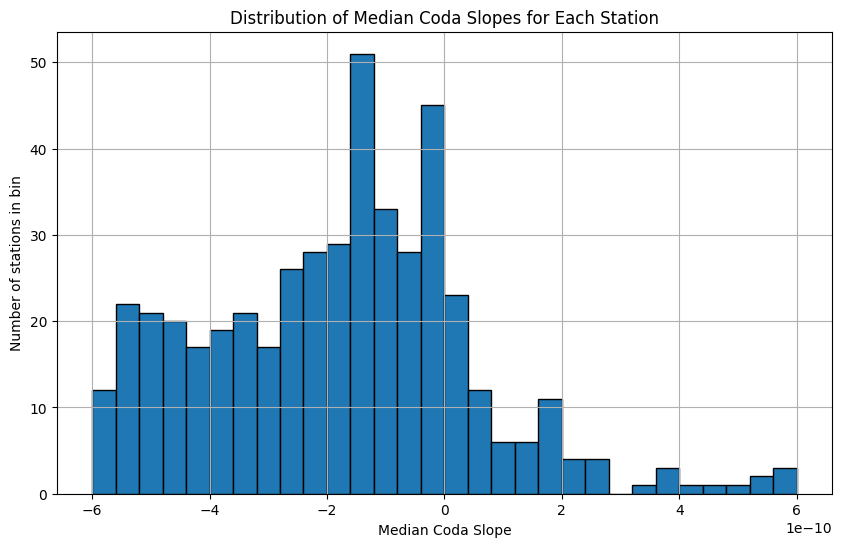

In [47]:

slope_medians = {}
for station, entries in coda_Q_dict.items():
    slopes = [entry['coda_slope'] for entry in entries if entry is not None and entry['coda_slope'] is not None]
    if slopes:
        slope_medians[station] = np.median(slopes)



plt.figure(figsize=(10, 6))
plt.hist(slope_medians.values(), bins=30,range=(-6e-10,6e-10), edgecolor='black')
plt.xlabel('Median Coda Slope')
plt.ylabel('Number of stations in bin')
plt.title('Distribution of Median Coda Slopes for Each Station')
plt.grid(True)
plt.show()

### Local Magnitude over Site Terms


In [97]:
import pandas as pd
from obspy import read, UTCDateTime
from obspy.geodetics import gps2dist_azimuth
from math import log10

stations_df = pd.read_csv('/home/schreinl/Stage/Data1/all_stations_coordinates.txt')


def calculate_local_magnitude(st, event_lat, event_lon, stations_df):
    ml_dict = {}
    for tr in st:
        station = tr.stats.station
        net = tr.stats.network
        time = tr.stats.starttime
        ampl = max(abs(tr.data))
        
        station_info = stations_df[stations_df['Station'] == station].iloc[0]
        station_lat = station_info['Latitude']
        station_lon = station_info['Longitude']
        
        epi_dist, _, _ = gps2dist_azimuth(event_lat, event_lon, station_lat, station_lon)
        epi_dist /= 1000  
        
        a = 0.018
        b = 2.17
        ml = log10(ampl * 1000) + a * epi_dist + b
        
        ml_dict[station] = {
            'network': net,
            'event_time': time,
            'Ml': ml
        }
    
    return ml_dict


#ml_dict = calculate_local_magnitude(st, event_lat, event_lon, stations_df)

#for station, info in ml_dict.items():
#    print(f"Station: {station}, Network: {info['network']}, Event Time: {info['event_time']}, Local Magnitude (Ml): {info['Ml']:.2f}")